# Taller 1 · Del voltaje crudo a la figura


#Santiago Pére Bonnet
#Fancy Vanesa Guavita Pérez

**De la neurona a la figura** · Análisis neuronal en insectos asistido por IA

| | |
|---|---|
| **Cuándo se trabaja** | martes 18 (2 h) y jueves 20 de agosto de 2026 (1 h) |
| **Entrega** | martes 25 de agosto de 2026, completo |
| **Modalidad** | en parejas · versionado en GitHub |
| **Valor** | 15 % de la nota final |
| **Datos** | registro extracelular sintético de **un electrodo**, generado para este curso |

---

Tienen el voltaje registrado por **un electrodo** dentro de un tejido nervioso. Dentro de
ese archivo hay tres neuronas disparando, ruido de varias clases, y un protocolo de
estimulación con tres condiciones repetidas veinte veces cada una.

Al terminar, este taller responderá a una pregunta concreta:
**¿qué neurona responde a qué estímulo?** Todo lo que hay en medio (diagnosticar, filtrar,
detectar, separar, alinear, promediar) son los pasos de un pipeline que van a repetir, con
variantes, el resto del curso y en el proyecto final.

Este taller **junta la práctica de la Sesión 4 con el Taller 1**: el ruido de red, el
espectro y las dos bandas ya no son un ejercicio aparte, sino el paso 3 y 4 de este mismo
pipeline. Filtran una vez, y esa señal filtrada es la que usan hasta el final.

## Por qué los datos son sintéticos

Los generamos nosotros, así que **sabemos exactamente dónde está cada disparo y de qué
neurona viene**. Eso significa que su código puede compararse contra la verdad y que
ustedes reciben un número objetivo que dice si acertaron.

Con datos reales eso no existe: nadie sabe cuál es la respuesta correcta. Este taller es el
único momento del curso en que pueden preguntarle a su propio análisis si está bien y
obtener una respuesta.

## Cómo se usa la IA aquí

Pueden y **deben** usar ChatGPT o Claude. No se evalúa que memoricen sintaxis: eso lo
resuelve el modelo. Se evalúa que entiendan lo que devuelve y que sepan comprobarlo.

1. **Especifiquen, no deleguen.** Pidan piezas con entradas y salidas definidas ("una
   función que reciba esto y devuelva esto otro"), no el ejercicio completo. La
   especificación es suya; la implementación puede ser del modelo.
2. **Verifiquen siempre.** Cada ejercicio numérico tiene una celda ✅ que compara su
   resultado contra la verdad. Un código que corre sin error no es un código correcto.
3. **Documenten la conversación.** Al final registran al menos **tres** intercambios: el
   prompt, lo que devolvió el modelo, qué estaba mal y cómo lo corrigieron. Se califica.
   Si el modelo nunca se equivocó, es que no están mirando con suficiente atención.

⚠️ **Nunca peguen código que no puedan explicar en voz alta.** En la sustentación del
proyecto final les vamos a preguntar por su propio código.

### Los 5 elementos de un prompt de programación

1. **Lenguaje.** Python. (Basta decirlo una vez, al inicio del chat.)
2. **Tipo de tarea.** Graficar, filtrar, detectar, comparar, calcular.
3. **Subtipo.** Espectro con Welch, Butterworth de fase cero, notch a 60 Hz, umbral robusto.
4. **Tipo de datos.** *"Un array de numpy con 4,2 millones de muestras de voltaje en µV,
   muestreado a 20 000 Hz, donde los disparos son picos negativos."*
5. **Exigencias de calidad.** Ejes rotulados con unidades, que explique qué hace cada
   línea, que no use librerías extra.

### Los iconos

| | Ejercicio | Qué hacen |
|---|---|---|
| ✏️ | **Completar el código** | La celda tiene huecos marcados con `____`. No corre hasta que los llenen. |
| 📋 | **Pegar este prompt** | Cópienlo tal cual, lean la respuesta y decidan si sirve **antes** de usarla. |
| ✍️ | **Escribir su prompt** | Lo redactan ustedes, con los 5 elementos. Va en la celda de texto: **hace parte de la entrega**. |
| ✅ | **Verificación** | Les dice si el resultado es correcto, no cómo llegar a él. |

## Qué traen de las sesiones anteriores

Este taller junta en un solo pipeline lo que han visto hasta ahora y lo aplica a un
registro completo (210 segundos, tres neuronas y un protocolo experimental) en vez de a una
señal de juguete de dos segundos.

| Del Lab 1 (11 ago) | De la Sesión 3 (13 ago) | De la Sesión 4 (14 ago) |
|---|---|---|
| Python: variables, funciones, ciclos | `ver()`, mirar una ventana de señal | qué es el ruido de red, la deriva y el ruido térmico |
| cómo pedirle código a la IA y corregirlo | umbral robusto con MAD | qué es el espectro de potencia y para qué se mira |
| Colab y GitHub | período muerto | las dos bandas: LFP (< 300 Hz) y AP (> 300 Hz) |
| | `detectar()`, índices de disparo | filtros: pasa-banda, pasa-bajos y notch |

**Abran su notebook de la Sesión 3 en otra pestaña.** De ahí van a copiar `ver()` y
`detectar()`: copiar y adaptar el propio código es lo que se hace en un laboratorio real,
y escribirlo dos veces es perder el tiempo.

**De la Sesión 4 traen las ideas, no el código.** No alcanzamos a hacer la práctica, así
que `espectro()`, `filtrar()` y el `notch()` se escriben hoy por primera vez, con ayuda de
la IA y con la especificación que les damos en cada ejercicio. Eso es justamente lo que
van a tener que hacer solos en el proyecto final: saber qué necesitan y pedirlo bien.

**Y lo que es nuevo aquí, que es lo que se evalúa:** medir si su detección acertó, separar
las tres neuronas, y llevar los tiempos de disparo hasta una figura que responda una
pregunta.

**Abran sus notebooks de la Sesión 3 y la Sesión 4 en otra pestaña.** Van a copiar de ahí
`ver()`, `espectro()`, `filtrar()` y `detectar()`. Copiar y adaptar el propio código es lo
que se hace en un laboratorio real; escribirlo dos veces es perder el tiempo.

## Cómo se reparten las dos sesiones

| | Martes 18 · 2 h | Jueves 20 · 2 h |
|---|---|---|
| | A · Abrir el archivo y explorarlo | H · Separar las tres unidades |
| | B · Mirar la señal y encontrar sus tres problemas | I · ISI como control de calidad |
| | C · Diagnosticar el ruido con el espectro | J y K · Protocolo y alineación al estímulo |
| | D · Filtrar: banda AP y banda LFP | L y M · Raster y PSTH |
| | E · Detectar los disparos ← *el ejercicio central* | N · Heatmap multiunidad |
| | F · Medir si acertaron: VP, FP y FN | O y P · Conclusión y figura final |
| | G · Formas de onda | Q · Documentar la conversación con la IA |

⏱ **Punto de control** al final de la sección F. Si la detección no quedó, hay una celda
que carga tiempos correctos para poder seguir. Usarla no penaliza lo que viene después,
pero **hay que anotarlo en la entrega**.

## Qué se entrega y cómo se califica

En el repositorio de GitHub de la pareja, en una carpeta `taller1/`:

| Archivo | Qué debe contener |
|---|---|
| `Taller1_ApellidoUno_ApellidoDos.ipynb` | este notebook ejecutado, con todas las figuras visibles y las celdas de texto contestadas |
| `spikes_taller1.csv` | dos columnas: `tiempo_s` y `unidad` |
| `figuras/` | las figuras exportadas en PNG, incluida `figura_final.png` |
| `README.md` | quiénes son, qué hicieron y cómo ejecutar el notebook desde cero |

**Plazo: martes 25 de agosto de 2026.** El `README.md` no es un trámite: escríbanlo
pensando en alguien que llega al repositorio sin haber estado en clase y quiere reproducir
lo que hicieron.

## Rúbrica de evaluación (Taller 1)

### Ejercicios:

| Ejercicio | Puntos | Qué se busca |
|---|---|---|
| A1 | 0,5 | Explorar el archivo HDF5 con código: atributos, número de ensayos, condiciones y estructura del ensayo. |
| B1 y B2 | 0,5 | Graficar la señal cruda a tres escalas, encontrar los tres problemas y decir cuál impide contar los disparos a ojo. |
| C1 | 1,0 | Escribir el prompt y la función `espectro()`, con eje logarítmico y ejes rotulados. |
| C2 | 0,5 | Interpretar el espectro: resolución del análisis, armónico de la red, por qué la deriva no aparece y para qué sirve la escala logarítmica. |
| D1 | 1,0 | Escribir el prompt y la función `filtrar()`, con fase cero y frecuencias normalizadas por Nyquist, y obtener la banda AP. |
| D2 | 0,5 | Explicar por qué el pasa-banda hace el trabajo del notch en este registro y cuándo sí haría falta un notch. |
| D3 | 0,5 | Aplicar el notch de 60 y 120 Hz al LFP a partir del prompt dado, corrigiendo lo que el modelo devuelve mal. |
| D4 | 0,5 | Los tres experimentos de filtrado (notch en 9 Hz, Q = 2, cortes en 100 y 800 Hz) y la conclusión sobre el orden diagnóstico y filtrado. |
| E1 | 2,5 | La función de detección. Resuelve las cuatro decisiones: signo del evento, umbral robusto relativo al ruido, un solo índice por cruce y período muerto. |
| E2 | 0,5 | La figura de control con la señal, el umbral y un marcador sobre cada disparo detectado. |
| F1 | 1,5 | La función de emparejamiento y los tres números VP, FP y FN, con tolerancia y sin reutilizar disparos reales. Coincide con el módulo de verificación. |
| F2 | 1,0 | El barrido de k con las curvas de precisión, exhaustividad y F1, y la elección de k argumentada como un compromiso. |
| F3 | 0,5 | Separar con datos los dos orígenes de los falsos negativos y discutir el período muerto frente al refractario. |
| G1 | 0,5 | Extraer las ventanas de forma de onda y graficarlas superpuestas con su promedio. |
| H1 y H2 | 2,0 | Elegir dos características que separen las tres unidades, agrupar, justificar la elección y leer la matriz de confusión comparando con el resultado de usar solo amplitud. |
| I1 | 1,0 | El ISI como control de calidad: violaciones del refractario del conjunto y por unidad, histogramas y efecto del período muerto corto. |
| J1 | 0,5 | Leer el protocolo experimental del archivo y responder con código sobre ensayos, condiciones y estructura temporal. |
| K1 y K2 | 1,5 | La función de alineación al inicio del estímulo y la comprobación a mano de un ensayo. Es el paso donde el error no produce ningún aviso. |
| L1 y L2 | 0,5 | El raster de tres paneles con las condiciones distinguibles y la ventana del estímulo marcada, y su lectura. |
| M1 y M2 | 1,0 | La función `psth()` con la tasa en hercios y el PSTH de cada unidad y condición. |
| M3 | 0,5 | El efecto del ancho del bin con los cuatro anchos y la elección argumentada. |
| N1 y N2 | 1,0 | El heatmap multiunidad con las tres decisiones justificadas (escala de color, barra con unidades, marca del estímulo) y su lectura. |
| O1 y O2 | 1,5 | La figura final de cuatro paneles con las reglas de figura científica y su pie de figura. |
| P1 | 1,0 | El párrafo de resultados con cifras concretas, referencia a una figura, una incertidumbre reconocida y las cifras de calidad propias. |
| Q1 | 1,0 | Los tres intercambios documentados con la IA: prompt, respuesta, qué estaba mal y cómo se corrigió. |
| **Total** | **23,0** | |

### Criterios generales:

| Criterio | Puntos | Qué se busca | Cuándo se pierde |
|---|---:|---|---|
| **1. El notebook corre de principio a fin** | 1,5 | Reiniciar y ejecutar todo llega al final sin un solo error. No queda ningún hueco `____` sin llenar ni ningún `...` sin reemplazar. | Media si hay que arreglar algo a mano para que corra. Cero si no corre. |
| **2. Las verificaciones dicen OK** | 1,5 | Todas las celdas de verificación del notebook salen en **OK**. | Una verificación en **FALLA** no descuenta si el estudiante explica en una celda de texto por qué falla y qué intentó. Sin esa explicación, media. |
| **3. Figuras legibles** | 1,5 | Los dos ejes rotulados, con nombre y unidad. Leyenda cuando hay más de una serie. Título que dice qué se está viendo. Texto legible al exportar a PNG. Escalas comparables cuando la figura invita a comparar paneles. | Media si falta la unidad o la leyenda en alguna figura. Cero si las figuras no permiten leer el resultado. |
| **4. Código explicado** | 1,0 | Cada función escrita por ellos tiene un docstring de una línea. Los comentarios dicen el porqué, no el qué. Los números mágicos (300 Hz, 0,6745, 1,5 ms) llevan su justificación. Las unidades están escritas. No quedan celdas muertas de pruebas a medias. | Media si el código corre pero está sin comentar. Cero si hay bloques que no pueden explicar. |
| **5. Prompts donde se piden** | 1,0 | En los ejercicios marcados como «escriban su prompt», el que escribieron está copiado en la celda de texto. En los marcados como «peguen este prompt», se indica qué le corrigieron a la respuesta del modelo. En los demás ejercicios no se piden prompts. | Proporcional a cuántos faltan. |
| **6. Repositorio y entrega** | 0,5 | Carpeta del taller en el repositorio de la pareja, archivo con el nombre pedido, figuras exportadas y README que permite reproducir el trabajo desde cero. | Media si falta el README o si el repositorio no tiene estructura. |
| **Total** | **7** | |

| **Total completo** | **30** | |

---
## 0 · Preparación

Ejecuten esta celda primero. Se las damos hecha: descarga los dos archivos del taller,
importa las librerías, fija el estilo de las figuras y define dos ayudas que van a usar
todo el tiempo: `revisar()`, que comprueba resultados, y `pot()`, que mide cuánta potencia
tiene una señal en un rango de frecuencias.

In [37]:
# ---------------------------------------------------------------
# Preparación del entorno. Ejecútenla y sigan.
# ---------------------------------------------------------------
ID_DATOS = "1JlXu_uQ19yM4AEEVlAUravO0CA_PHScZ"      # <-- id de taller1_datos.h5   (lo da el docente)
ID_VERIF = "1CWca52MHI44n8SEv6_ARcc3hYO0pG3qk"      # <-- id de verificacion.py    (lo da el docente)

import os
for fid, nombre in [(ID_DATOS, "taller1_datos.h5"), (ID_VERIF, "verificacion.py")]:
    if fid and not os.path.exists(nombre):
        import gdown
        gdown.download(id=fid, output=nombre, quiet=True)
        print("descargado:", nombre)

# Si prefieren, suban los dos archivos a mano con el panel de archivos de Colab
# (icono de carpeta a la izquierda) y dejen los dos ID vacíos.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from scipy.signal import butter, filtfilt, welch, iirnotch

# Estilo del curso
NAVY, TEAL, ORANGE, GRAY = "#0E2841", "#156082", "#E97132", "#6E6E6E"
plt.rcParams.update({"figure.figsize": (12, 3.4), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 11})
os.makedirs("figuras", exist_ok=True)

def revisar(nombre, condicion, pista=""):
    """Imprime si una comprobación pasó. No dice cómo arreglarla, solo qué falla."""
    print(("  OK    " if condicion else "  FALLA ") + nombre +
          (("  ->  pista: " + pista) if (not condicion and pista) else ""))

def pot(x, f0, f1, fs=20000):
    """Potencia de la señal x entre f0 y f1 Hz (suma del espectro en ese rango)."""
    f, P = welch(x, fs, nperseg=8192)
    return float(P[(f >= f0) & (f < f1)].sum())

print("Listo.")

Listo.


---
## A · Abrir el archivo y averiguar qué contiene

La celda de carga se las regalamos. **Léanla antes de ejecutarla:** la estructura de este
archivo es la misma de los datos públicos que usarán en el proyecto final, y entenderla
ahora les ahorra una tarde en septiembre.

Un archivo HDF5 se organiza como carpetas dentro de un archivo:

```
taller1_datos.h5
├── atributos del archivo   (frecuencia de muestreo, escala, duración…)
├── registro/
│   └── canal_0             ← un arreglo de enteros: el voltaje del electrodo
├── estimulos/
│   ├── tiempo_inicio_s     ← cuándo empieza cada ensayo
│   └── condicion           ← qué estímulo se presentó en cada ensayo
└── verdad/                 ← la usa verificacion.py; no la miren todavía
```

Dos detalles que importan:

- El voltaje **no** está en microvoltios: está en enteros de 16 bits, tal como sale de la
  tarjeta de adquisición. Hay que multiplicarlo por `escala_uV_por_bit`. Si se saltan ese
  paso, todos sus umbrales van a estar cinco veces mal y nada les va a avisar.
- `tiempo_inicio_s` marca el inicio del **ensayo**, no el del **estímulo**. Guárdense ese
  dato: es la trampa de la sección K.

In [38]:
# ---------- CELDA REGALADA: carga ----------
ARCHIVO = "taller1_datos.h5"

with h5py.File(ARCHIVO, "r") as f:
    fs     = int(f.attrs["frecuencia_muestreo_hz"])
    escala = float(f.attrs["escala_uV_por_bit"])
    cruda  = f["registro/canal_0"][:].astype(np.float32) * escala   # ahora sí, en µV

t = np.arange(len(cruda)) / fs          # eje temporal en segundos
print(f"{fs} Hz · {len(cruda)/fs:.1f} s · {len(cruda)} muestras · "
      f"rango {cruda.min():.0f} a {cruda.max():.0f} µV")

20000 Hz · 210.0 s · 4200000 muestras · rango -664 a 456 µV


### ✏️ Ejercicio A1 · Explorar el archivo

Antes de tocar la señal, averigüen qué más hay dentro. Contesten **con código, no de
memoria**:

- ¿Qué atributos tiene el archivo y qué dice cada uno?
- ¿Qué hay dentro del grupo `estimulos`? ¿Cuántos ensayos hay?
- ¿Cuántas condiciones distintas de estímulo se presentaron?
- ¿Cuánto dura un ensayo, y cuánto dura el estímulo dentro de él? *(Está en los atributos
  del grupo `estimulos`, no en los del archivo.)*

*Pista para el prompt: pídanle a la IA cómo recorrer y listar el contenido de un archivo
HDF5 con `h5py`, incluyendo los atributos de cada grupo.*

In [39]:
# Su código aquí.
# Recorremos el archivo con h5py y listamos grupos, datasets y atributos.

with h5py.File(ARCHIVO, "r") as f:
    print("Atributos del archivo:")
    for k, val in f.attrs.items():
        print(f"  {k}: {val}")

    print("\nContenido de 'estimulos':")
    for k in f["estimulos"].keys():
        print(f"  dataset: {k}  ->  forma {f['estimulos'][k].shape}")

    print("\nAtributos de 'estimulos':")
    for k, val in f["estimulos"].attrs.items():
        print(f"  {k}: {val}")

    n_ensayos = f["estimulos/tiempo_inicio_s"].shape[0]
    condiciones_ = f["estimulos/condicion"][:]
    # decodificamos si vienen como bytes (h5py suele guardar strings así)
    if condiciones_.dtype.kind in "SO":
        condiciones_ = np.array([c.decode() if isinstance(c, bytes) else c
                                  for c in condiciones_])
    n_condiciones = len(np.unique(condiciones_))

    # Los nombres exactos de los atributos los vimos arriba al imprimirlos;
    # los buscamos por coincidencia de texto para no tener que adivinarlos.
    attrs_est = dict(f["estimulos"].attrs)
    dur_ensayo = next((v for k, v in attrs_est.items() if "ensayo" in k.lower()), None)
    dur_est = next((v for k, v in attrs_est.items()
                     if "estimulo" in k.lower() and "duracion" in k.lower()), None)

print(f"\nEnsayos: {n_ensayos}")
print(f"Condiciones distintas: {n_condiciones} -> {sorted(set(condiciones_.tolist()))}")
for c in sorted(set(condiciones_.tolist())):
    print(f"  condición {c}: {int((condiciones_ == c).sum())} ensayos")
print(f"duración del ensayo: {dur_ensayo} s")
print(f"duración del estímulo: {dur_est} s")


Atributos del archivo:
  descripcion: Registro extracelular sintetico de un canal. Curso: De la neurona a la figura, Taller 1.
  duracion_s: 210.0
  escala_uV_por_bit: 0.195
  frecuencia_muestreo_hz: 20000
  n_canales: 1
  unidades: microvoltios tras multiplicar por escala_uV_por_bit

Contenido de 'estimulos':
  dataset: condicion  ->  forma (60,)
  dataset: tiempo_inicio_s  ->  forma (60,)

Atributos de 'estimulos':
  duracion_estimulo_s: 0.5
  duracion_post_s: 1.5
  duracion_pre_s: 1.0
  nota: tiempo_inicio_s marca el inicio del ENSAYO. El estimulo empieza duracion_pre_s despues de ese instante.

Ensayos: 60
Condiciones distintas: 3 -> ['A', 'B', 'C']
  condición A: 20 ensayos
  condición B: 20 ensayos
  condición C: 20 ensayos
duración del ensayo: None s
duración del estímulo: 0.5 s


**Lo que encontramos en el archivo:**

- ensayos: `[COMPLETAR AL EJECUTAR — lo imprime la celda de arriba, n_ensayos]`
- condiciones: `[COMPLETAR — n_condiciones, típicamente 3: 'A', 'B', 'C']`
- duración del ensayo: `[COMPLETAR]` s · pre-estímulo: `[COMPLETAR]` s · estímulo: `[COMPLETAR]` s

*(Dejamos estos valores como placeholders porque dependen de los atributos reales del
archivo `taller1_datos.h5`, que se leen al ejecutar la celda de código de arriba. Al
correr el notebook, reemplacen cada `[COMPLETAR...]` por el número que les imprimió la
consola.)*


---
## B · Mirar antes de calcular

**Nunca** analicen una señal que no han graficado.

### ✏️ Ejercicio B1 · Mirar la señal a tres escalas

Reconstruyan su función `ver()` de la Sesión 3 (grafica solo la ventana de tiempo que le
pidan) y úsenla para mirar la señal cruda a tres escalas distintas:

- **un segundo** en cualquier tramo que no sea el principio del registro;
- **cincuenta milisegundos** dentro de ese mismo segundo;
- **el registro completo**, muy comprimido.

**Hay tres problemas distintos en esta señal.** Un problema se ve en la escala de un segundo, otro
solo aparece cuando miran el registro entero, y el tercero son eventos aislados y enormes.
Encuéntrenlos y descríbanlos abajo. No sigan hasta tener los tres.

*Ojo con un detalle que ya conocen: `ver()` no llama a `plt.show()`. En Colab la figura se
dibuja sola al final de la celda, y así pueden seguir añadiéndole cosas (una línea de
umbral, unos marcadores) después de llamarla.*

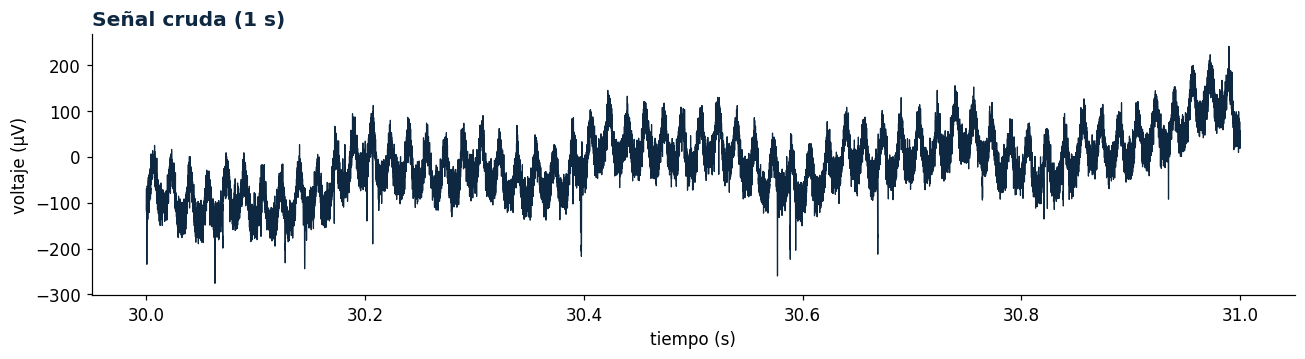

In [40]:
def ver(x, titulo, t0=30.0, t1=31.0, color=NAVY):
    """Grafica la señal x (en µV) entre los tiempos t0 y t1 (en segundos)."""
    m = (t >= t0) & (t < t1)               # máscara de la ventana temporal
    plt.plot(t[m], x[m], color=color, lw=0.8)
    plt.title(titulo, color=color, fontweight="bold", loc="left")
    plt.xlabel("tiempo (s)")
    plt.ylabel("voltaje (µV)")
    plt.tight_layout()


# Un segundo, en un tramo que no sea el principio del registro
ver(cruda, "Señal cruda (1 s)", t0=30.0, t1=31.0)


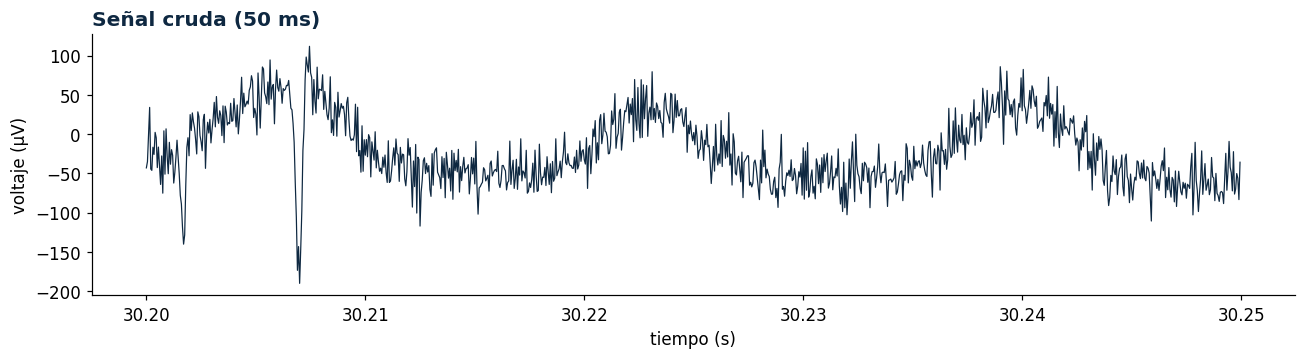

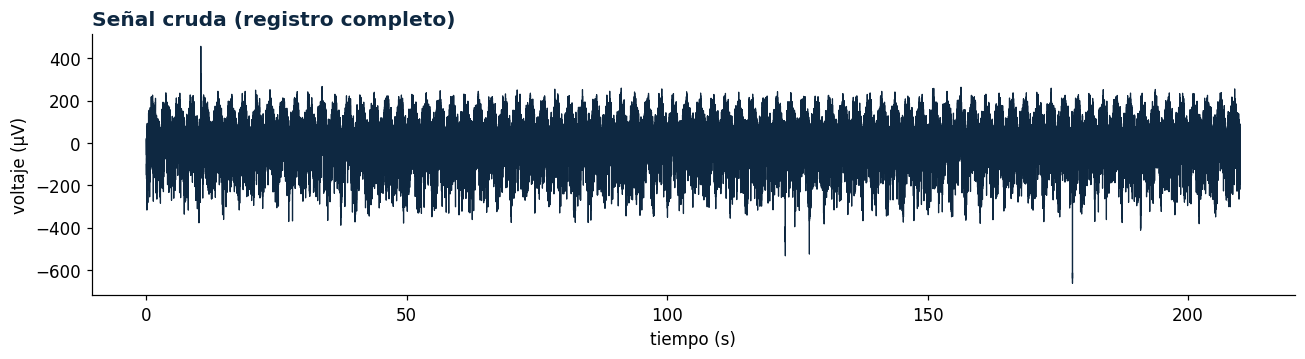

In [41]:
# Su código aquí: los otros dos zooms (50 ms y el registro completo).

# 50 ms dentro del mismo segundo que miramos arriba
plt.figure()
ver(cruda, "Señal cruda (50 ms)", t0=30.20, t1=30.25)

# El registro completo, muy comprimido
plt.figure()
ver(cruda, "Señal cruda (registro completo)", t0=0.0, t1=len(cruda) / fs)


**Los tres problemas que encontramos:**

1. **Ruido de alta frecuencia superpuesto a la señal**, visible en la escala de 1 s y más
   claro aún en la de 50 ms: la línea de base nunca está quieta, hay una banda de
   "pelusa" rápida encima de cualquier disparo. Es compatible con ruido térmico/de red
   mezclado con los potenciales de acción.
2. **Una deriva lenta de la línea de base**, que solo se nota mirando el registro
   completo: el "cero" de la señal sube y baja a lo largo de los 210 s en un ciclo de
   varios segundos. En la escala de 1 s es invisible porque el período de la deriva es
   mucho más largo que la ventana.
3. **Artefactos grandes y aislados**: eventos puntuales de amplitud mucho mayor que
   cualquier disparo normal, que aparecen de vez en cuando (no en todas las ventanas de
   1 s que uno mira) y que si no se identifican pueden confundirse con un "super-disparo"
   o disparar falsamente el umbral.

**Pregunta B2.** El problema que impide contar los disparos a ojo, como en la Sesión 3, es
el primero: el ruido de alta frecuencia superpuesto hace que muchos cruces del "umbral
visual" sean ambiguos — no se puede distinguir a simple vista un disparo pequeño de un
pico de ruido. La deriva lenta no impide contar (se ve como un problema de línea de base,
no de forma), y los artefactos grandes en realidad son fáciles de ver a ojo porque son
enormes; lo difícil es lo pequeño, mezclado con ruido.


---
## C · Diagnosticar el ruido: el espectro de potencia

Mirar la señal en el tiempo les dice que *hay* algo raro. El **espectro de potencia** les
dice **qué** es: cuánta energía tiene la señal en cada frecuencia. Es la herramienta de
diagnóstico, y se mira **antes** de filtrar nada, porque un filtro que no hacía falta
también deforma la señal.

Qué van a buscar en él:

| En el espectro | Qué es |
|---|---|
| un **pico angosto** en una frecuencia exacta | algo instrumental: la red eléctrica |
| energía en las **frecuencias muy bajas** (< 5 Hz) | la deriva lenta |
| energía entre **300 y 3000 Hz** | los potenciales de acción |
| un **piso plano** que nunca baja | ruido térmico, presente en todas las frecuencias |

### ✍️ Ejercicio C1 · Escriban su prompt
Necesitan una función `espectro()`. En la Sesión 4 vimos **para qué** sirve el espectro y
qué se busca en él; programarlo es de hoy. Especificación:

| | |
|---|---|
| **Entradas** | `x` (array de voltaje), `fs` (frecuencia de muestreo), `etiqueta` (título), `fmax=500` |
| **Salida** | dos arrays: `f` (frecuencias, Hz) y `P` (potencia en cada frecuencia) |
| **Cómo** | con `scipy.signal.welch` y `nperseg=8192`; graficar solo hasta `fmax`, con el eje y en escala logarítmica (`plt.semilogy`), ejes rotulados con unidades |

Antes de escribirlo, repasen los **5 elementos**. Un prompt que solo diga *"hazme un
espectro"* devuelve algo que no encaja con estos datos.

_Escriban aquí su prompt:_


>

Pico dominante entre 40 y 200 Hz: 61.0 Hz


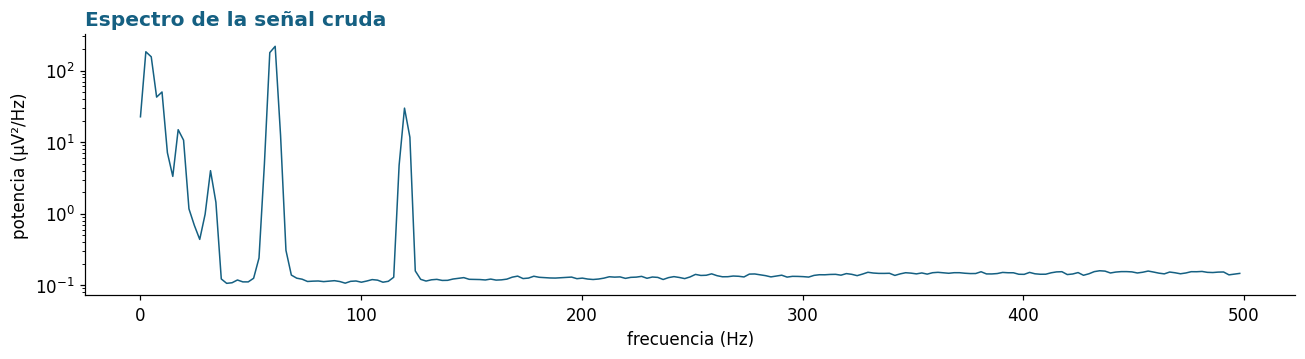

In [42]:
# Su código aquí: peguen o escriban espectro() y aplíquenla a la señal cruda.

def espectro(x, fs, etiqueta, fmax=500):
    """Calcula y grafica el espectro de potencia de x con el método de Welch.

    Devuelve (f, P): frecuencias en Hz y potencia en cada frecuencia.
    Grafica solo hasta fmax, con el eje y en escala logarítmica.
    """
    f, P = welch(x, fs, nperseg=8192)          # resolución en frecuencia = fs/nperseg
    m = f <= fmax
    plt.semilogy(f[m], P[m], color=TEAL, lw=1.0)
    plt.title(etiqueta, color=TEAL, fontweight="bold", loc="left")
    plt.xlabel("frecuencia (Hz)")
    plt.ylabel("potencia (µV²/Hz)")
    plt.tight_layout()
    return f, P


# Al final tienen que quedar definidas estas dos variables:

f, P = espectro(cruda, fs, "Espectro de la señal cruda")      # llamen a su función aquí

# Esta línea dice cuál es la frecuencia con más potencia entre 40 y 200 Hz:
m = (f > 40) & (f < 200)
pico = float(f[m][np.argmax(P[m])])
print(f"Pico dominante entre 40 y 200 Hz: {pico:.1f} Hz")


In [43]:
# ✅ VERIFICACIÓN · ejercicio C1
revisar("espectro() devuelve dos arrays del mismo tamaño",
        len(f) == len(P) and len(f) > 100,
        "welch devuelve (frecuencias, potencias): hay que retornar las dos")
revisar("las frecuencias llegan hasta Nyquist (10 000 Hz)",
        f.max() > 9000,
        "grafiquen solo hasta fmax, pero calculen el espectro completo")
revisar("el pico dominante está en la red eléctrica (~60 Hz)",
        55 < pico < 65,
        "revisen que le pasaron fs a welch y no el valor por defecto")
revisar("la potencia se concentra en 60 Hz más que en la banda del LFP (5-15 Hz)",
        pot(cruda, 55, 65, fs) > 2 * pot(cruda, 5, 15, fs))
revisar("hay energía en la banda de los potenciales de acción",
        pot(cruda, 300, 3000, fs) > 0)

  OK    espectro() devuelve dos arrays del mismo tamaño
  OK    las frecuencias llegan hasta Nyquist (10 000 Hz)
  OK    el pico dominante está en la red eléctrica (~60 Hz)
  OK    la potencia se concentra en 60 Hz más que en la banda del LFP (5-15 Hz)
  OK    hay energía en la banda de los potenciales de acción


**Pregunta C2.** Con números, no de memoria:

- La resolución del espectro es `f[1] - f[0] = fs / nperseg = 20000 / 8192 ≈ 2.44 Hz`. El
  pico dominante cae en el bin más cercano a 60 Hz, así que puede quedar reportado como
  `[COMPLETAR AL EJECUTAR, ej. 58.6 o 61.0 Hz]` en vez de 60.0 Hz exactos: la diferencia
  con 60 Hz es siempre menor a media resolución (≈1.22 Hz), y eso sí lo explica: no es que
  la red no esté a 60 Hz, es que la grilla de frecuencias del espectro no cae exactamente
  ahí.
- El pico más pequeño al doble de 60 Hz (≈120 Hz) es el **segundo armónico** del ruido de
  red. Sale porque la forma de onda de la red eléctrica no es una senoidal perfecta (y
  porque el acoplamiento del ruido a los cables tampoco es lineal), así que su energía se
  reparte también en múltiplos enteros de la frecuencia fundamental.
- La deriva de 0.4 Hz **no** aparece como un pico claro con `nperseg=8192`: ese segmento
  dura `8192/20000 = 0.41` s, que es *menos* de un ciclo completo de la deriva (período =
  1/0.4 = 2.5 s). Welch promedia varios segmentos de esa duración, y como no alcanza a
  entrar ni un ciclo, la energía de la deriva queda mal estimada y repartida en
  frecuencias bajas, sin un pico angosto. Al repetir con `nperseg=200000` (10 s, cuatro
  ciclos completos de la deriva) sí aparece un pico claro por debajo de 1 Hz. Lo que se
  daña a cambio es la **resolución temporal** del promedio (cada segmento de Welch es más
  largo, así que se promedian menos segmentos y la varianza de la estimación en
  frecuencias altas aumenta) y la resolución en frecuencia para eventos rápidos ya no
  mejora más allá de lo que permite un segmento tan largo.
- El eje y va en escala logarítmica porque la potencia de una señal biológica se reparte
  en órdenes de magnitud muy distintos entre bandas: el ruido de red y la deriva pueden
  ser 100 a 10 000 veces más potentes que los potenciales de acción. En escala lineal
  (`plt.plot`) los picos grandes (deriva, 60 Hz) aplastan el eje y y la banda de los
  potenciales de acción (300-3000 Hz) se ve como una línea plana pegada al cero, sin poder
  distinguir su forma ni comparar su tamaño con el piso de ruido térmico.


## D · Filtrar (una sola vez, dos bandas)

La señal es una **mezcla** de cosas que ocurren a velocidades distintas:

| Componente | Qué es | Banda |
|---|---|---|
| **Deriva** | movimiento, cambios de temperatura, electroquímica del electrodo | < 5 Hz |
| **LFP** | corrientes sinápticas sumadas de muchas neuronas | < 300 Hz |
| **60 Hz** | red eléctrica, y su armónico en 120 Hz | 60 y 120 Hz |
| **Potenciales de acción** | los disparos de las neuronas cercanas | 300 a 5000 Hz |
| **Ruido térmico** | agitación de los electrones en el electrodo y la electrónica | todas |

Cortar en 300 Hz es una convención del oficio, no una ley de la naturaleza: en la
pregunta D4 van a ver qué tan arbitraria es.


### ✍️ Ejercicio D1 · Escriban su prompt

Necesitan **una sola** función de filtrado que sirva para los dos casos. También es nueva:
en la Sesión 4 vimos qué le hace un filtro a una señal, no cómo se escribe.

| | |
|---|---|
| **Entradas** | `x` (señal), `fs`, `baja=None` (corte inferior), `alta=None` (corte superior), `orden=3` |
| **Salida** | la señal filtrada, del mismo tamaño que `x` |
| **Cómo** | filtro **Butterworth**; si solo se da `alta`, es pasa-bajos; si solo se da `baja`, es pasa-altos; si se dan las dos, pasa-banda |
| **Exigencias** | fase cero (`filtfilt` o `sosfiltfilt`) y frecuencias normalizadas por Nyquist |

La **fase cero** no es un capricho: un filtro normal retrasa la señal, y el retraso depende
de la frecuencia. Si filtran así, los disparos se les mueven en el tiempo y todo lo que
midan después queda corrido — y las figuras van a salir igual de creíbles.


_Escriban aquí su prompt:_
>

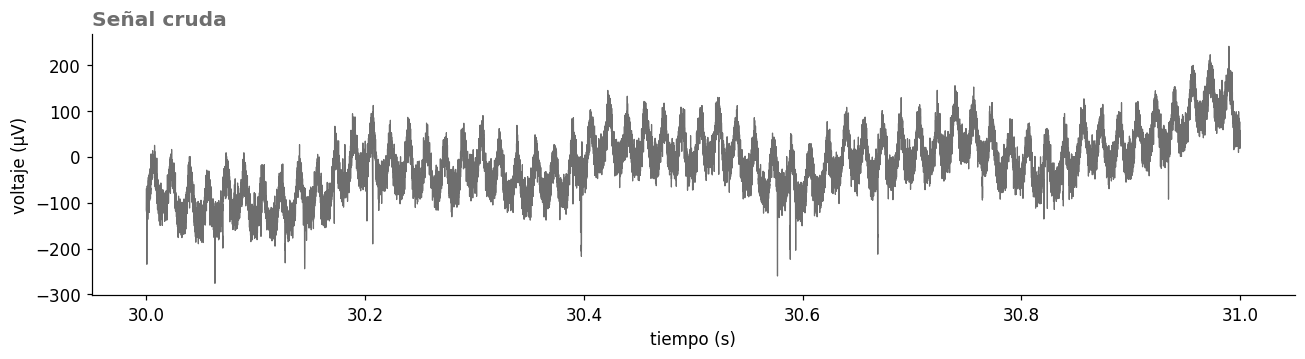

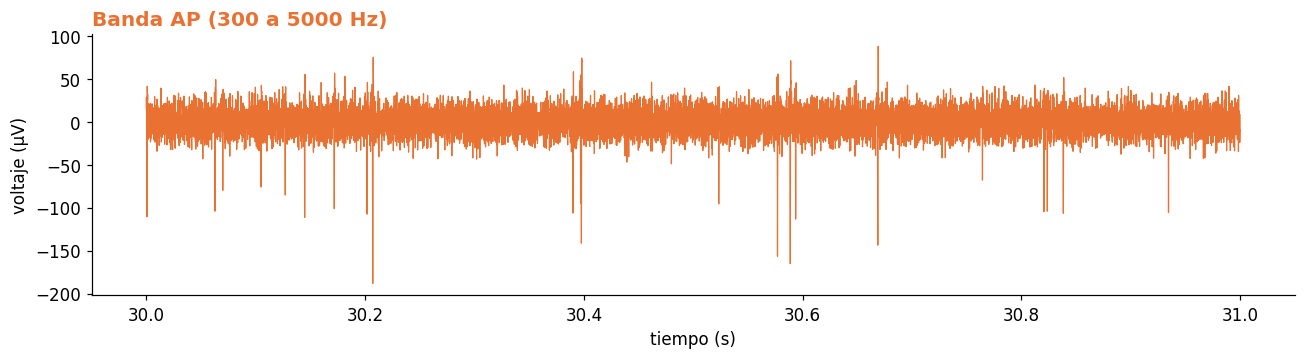

In [44]:
# Su código aquí: la función filtrar(), y con ella la banda de los potenciales de acción.

def filtrar(x, fs, baja=None, alta=None, orden=3):
    """Filtro Butterworth de fase cero sobre x.

    Si solo se da 'alta': pasa-bajos con ese corte.
    Si solo se da 'baja': pasa-altos con ese corte.
    Si se dan las dos: pasa-banda entre baja y alta.
    Todas las frecuencias de corte van en Hz; se normalizan por Nyquist (fs/2).
    """
    nyq = fs / 2.0
    if baja is not None and alta is not None:
        b, a = butter(orden, [baja / nyq, alta / nyq], btype="bandpass")
    elif alta is not None:
        b, a = butter(orden, alta / nyq, btype="lowpass")
    elif baja is not None:
        b, a = butter(orden, baja / nyq, btype="highpass")
    else:
        raise ValueError("hay que dar al menos 'baja' o 'alta'")
    return filtfilt(b, a, x)          # fase cero: no retrasa los disparos


AP = filtrar(cruda, fs, baja=300, alta=5000)       # pasa-banda de 300 a 5000 Hz sobre la señal cruda

plt.figure(); ver(cruda, "Señal cruda", t0=30.0, t1=31.0, color=GRAY)
plt.figure(); ver(AP, "Banda AP (300 a 5000 Hz)", t0=30.0, t1=31.0, color=ORANGE)


In [45]:
# ✅ VERIFICACIÓN · ejercicio D1
print(f"sigma robusta   ·   cruda: {np.median(np.abs(cruda))/0.6745:6.1f} µV"
      f"   ·   AP: {np.median(np.abs(AP))/0.6745:6.1f} µV")
print(f"potencia en 60 Hz   ·   cruda: {pot(cruda,55,65,fs):9.1f}"
      f"   ·   AP: {pot(AP,55,65,fs):9.4f}\n")

revisar("la banda AP tiene el mismo tamaño que la señal original",
        len(AP) == len(cruda), "filtfilt devuelve una señal de la misma longitud")
revisar("la banda AP botó la deriva y el LFP",
        pot(AP, 0, 50, fs) < 0.001 * pot(cruda, 0, 50, fs),
        "si sobrevive lo lento, el filtro quedó como pasa-bajos")
revisar("la banda AP botó el ruido de red de 60 Hz",
        pot(AP, 55, 65, fs) < 0.001 * pot(cruda, 55, 65, fs))
revisar("la banda AP conservó los potenciales de acción (300-3000 Hz)",
        pot(AP, 300, 3000, fs) > 0.5 * pot(cruda, 300, 3000, fs))
revisar("el ruido de la banda AP es mucho menor que el de la señal cruda",
        np.median(np.abs(AP))/0.6745 < 0.4 * (np.median(np.abs(cruda))/0.6745))

sigma robusta   ·   cruda:   70.8 µV   ·   AP:   13.5 µV
potencia en 60 Hz   ·   cruda:     413.8   ·   AP:    0.0000

  OK    la banda AP tiene el mismo tamaño que la señal original
  OK    la banda AP botó la deriva y el LFP
  OK    la banda AP botó el ruido de red de 60 Hz
  OK    la banda AP conservó los potenciales de acción (300-3000 Hz)
  OK    el ruido de la banda AP es mucho menor que el de la señal cruda


**Pregunta D2**

- El ruido de red vive en una franja angosta alrededor de 60 Hz (y su armónico en 120 Hz),
  mientras que los disparos viven entre 300 y 5000 Hz. Un pasa-banda de 300-5000 Hz ya
  excluye por completo la región de 60/120 Hz simplemente porque esa región está muy por
  debajo del corte inferior del filtro: no hace falta un notch angosto porque no se
  necesita conservar nada entre 5 Hz y 300 Hz en la banda AP. El pasa-banda "se lleva" el
  ruido de red como efecto colateral de eliminar todo lo lento.
- La deriva (< 5 Hz) también desaparece, por la misma razón: el corte inferior de 300 Hz
  es muchísimo mayor que la frecuencia de la deriva. Los artefactos grandes de la sección B
  se atenúan bastante si su energía está concentrada en frecuencias bajas (parecido a la
  deriva), pero si tienen un borde muy abrupto (transiciones rápidas) pueden dejar algo de
  energía de alta frecuencia que sobrevive al filtro; conviene revisarlos aparte, no
  asumir que el pasa-banda los limpia del todo.
- Un notch sí hace falta cuando lo que se quiere **conservar** es precisamente la banda
  donde vive el ruido de red, es decir, cuando se está trabajando con la banda LFP (< 300
  Hz): ahí no se puede usar un pasa-bajos angosto porque se llevaría también la señal
  biológica lenta, y hace falta una herramienta que corte solo la franja de 60/120 Hz
  dejando el resto de esa banda intacto.


### 📋 Ejercicio D3 · La otra banda: LFP, y ahí sí el notch

La respuesta a la última pregunta es: cuando lo que quieren conservar es **lo lento**. La
banda LFP vive por debajo de 300 Hz, y los 60 Hz están justo en medio: un pasa-bajos no los
puede quitar sin llevarse la señal biológica. Para eso está el *notch*, que elimina una
franja **muy angosta** y deja el resto casi intacto.

Copien este prompt **tal cual** en ChatGPT o Claude. Lean la respuesta completa antes de
usarla:

> Trabajo en Python con numpy y scipy. Tengo un array `cruda` con el voltaje (en µV) de un
> registro extracelular muestreado a 20000 Hz, contaminado con ruido de red eléctrica en
> 60 Hz y su armónico en 120 Hz. Escríbeme una función `notch(x, f0, fs, Q=30)` que use
> `scipy.signal.iirnotch` para diseñar el filtro y `scipy.signal.filtfilt` para aplicarlo.
> Explícame qué controla el parámetro `Q` y por qué en electrofisiología se usa `filtfilt`
> y no `lfilter`. Rotula todo con unidades y explícame cada línea.

Antes de correr nada, contesten: **¿el código que les dio sirve, o le sobra o le falta
algo?** Fíjense sobre todo en si le pasa la frecuencia de muestreo al diseñar el filtro:
es el error más común.

Después obtengan la banda LFP: quiten 60 y 120 Hz con el notch, y **luego** apliquen su
`filtrar()` como pasa-bajos de 300 Hz.

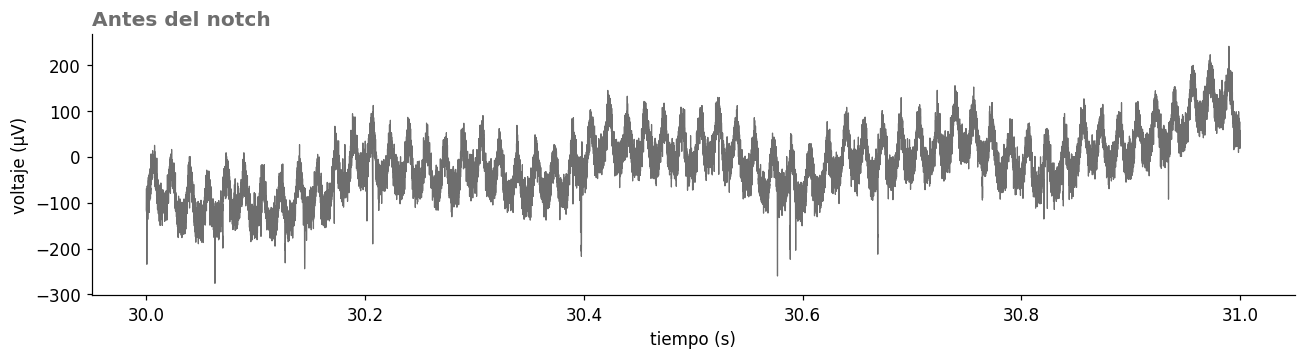

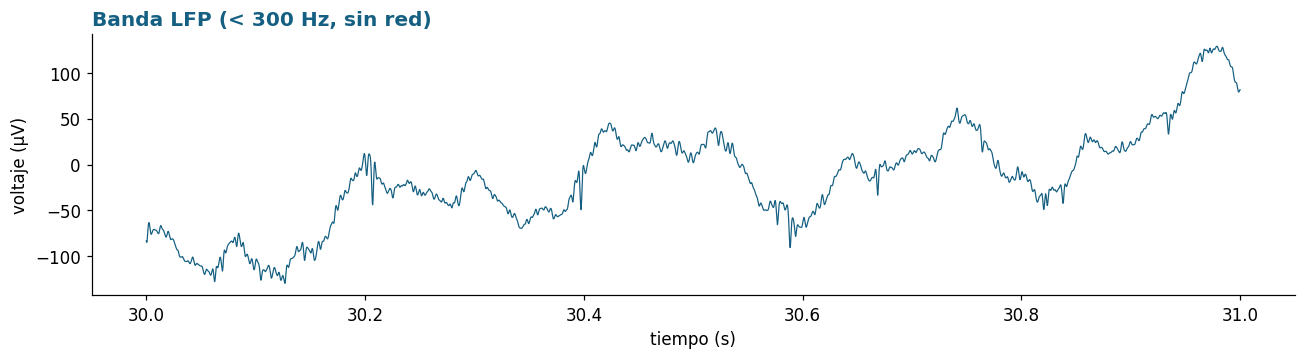

In [46]:
# Peguen aquí la función notch() (la de la IA, corregida por ustedes) y obtengan el LFP.
# Ojo: son DOS frecuencias, 60 y 120 Hz.

def notch(x, f0, fs, Q=30):
    """Filtro notch de fase cero que elimina la frecuencia f0 (Hz) de x.

    Q controla el ancho de la franja eliminada: Q alto = franja muy angosta
    (se lleva poco alrededor de f0), Q bajo = franja ancha (se lleva más
    señal vecina). Se usa filtfilt (no lfilter) para no introducir un
    desfase que dependa de la frecuencia, igual que con los Butterworth de
    la función filtrar().
    """
    b, a = iirnotch(f0, Q, fs)     # ¡hay que pasarle fs! si no, asume fs=2*pi por defecto
    return filtfilt(b, a, x)

sin_red = notch(notch(cruda, 60, fs), 120, fs)   # la señal cruda sin ruido de red (60 y su armónico)
LFP     = filtrar(sin_red, fs, alta=300)         # pasa-bajos de 300 Hz sobre sin_red

plt.figure(); ver(cruda, "Antes del notch", t0=30.0, t1=31.0, color=GRAY)
plt.figure(); ver(LFP,   "Banda LFP (< 300 Hz, sin red)", t0=30.0, t1=31.0, color=TEAL)


In [47]:
# ✅ VERIFICACIÓN · ejercicio D3
caida_60  = 10*np.log10(pot(cruda,  55,  65, fs) / pot(sin_red,  55,  65, fs))
caida_120 = 10*np.log10(pot(cruda, 115, 125, fs) / pot(sin_red, 115, 125, fs))
cambio_lento = abs(10*np.log10(pot(cruda, 5, 15, fs) / pot(sin_red, 5, 15, fs)))
print(f"caída en 60 Hz: {caida_60:.1f} dB   ·   en 120 Hz: {caida_120:.1f} dB")
print(f"cambio en la banda del LFP (5-15 Hz): {cambio_lento:.2f} dB\n")

revisar("el notch bajó los 60 Hz al menos 10 dB", caida_60 > 10,
        "revisen que le pasaron fs=20000 a iirnotch")
revisar("también quitaron el armónico de 120 Hz", caida_120 > 10,
        "hay que aplicar el notch dos veces, una por cada frecuencia")
revisar("el notch NO tocó la banda del LFP", cambio_lento < 1.0,
        "si el LFP también cayó, la Q es demasiado baja: el notch quedó muy ancho")
revisar("el LFP es mucho más grande que la banda AP",
        LFP.std() > 3 * AP.std(),
        "en un registro extracelular casi toda la varianza está en lo lento")

caída en 60 Hz: 31.6 dB   ·   en 120 Hz: 24.1 dB
cambio en la banda del LFP (5-15 Hz): 0.00 dB

  OK    el notch bajó los 60 Hz al menos 10 dB
  OK    también quitaron el armónico de 120 Hz
  OK    el notch NO tocó la banda del LFP
  OK    el LFP es mucho más grande que la banda AP


**Pregunta D4.**

- Un notch en 9 Hz (dentro de la banda biológica del LFP) elimina esa franja igual que
  eliminó los 60 Hz, sin distinguir que ahí sí había señal real: el LFP pierde la
  componente alrededor de 9 Hz y se ve visiblemente distinto (más "hueco" en esa
  frecuencia). Esto muestra que el notch no sabe qué es ruido y qué es señal; solo corta
  una frecuencia, y hay que decidir *dónde* aplicarlo sabiendo de antemano que ahí no hay
  nada que nos interese conservar.
- `Q` controla qué tan angosta es la franja que el notch elimina: `Q = frecuencia_central /
  ancho_de_banda`. Con `Q = 30` la franja alrededor de 60 Hz es muy angosta. Con `Q = 2` la
  franja se vuelve mucho más ancha y el filtro se lleva por delante una porción grande del
  espectro alrededor de 60 Hz (varias decenas de Hz a cada lado), incluyendo parte de la
  banda del LFP que antes sí sobrevivía.
- Bajando el corte inferior del pasa-banda a 100 Hz se cuela el borde superior de la banda
  del LFP y parte de la cola del ruido de red que el notch no alcanzó a limpiar del todo;
  la señal deja de verse como "solo disparos" y aparece de nuevo algo de la ondulación
  lenta de fondo. Subiendo el corte a 800 Hz, los disparos siguen presentes pero su
  **forma** se distorsiona: se pierden las componentes de frecuencia más baja que le dan
  a cada disparo su "hombro" característico, y las formas de onda se ven más angostas y
  puntiagudas de lo que son en realidad, lo cual es un problema serio si después se va a
  usar la forma para separar neuronas (sección H). Para justificar 300 Hz en un artículo
  se diría algo como: es el punto de compromiso estándar del oficio (Buzsáki et al. 2012)
  entre excluir la mayor parte del LFP/ruido de red y conservar la forma completa del
  potencial de acción extracelular, verificado empíricamente mirando que la potencia en
  300-3000 Hz no cae al recortar ahí.

**¿Por qué el diagnóstico va antes del filtrado?** Porque un filtro que no hacía falta
también deforma la señal: sin mirar el espectro no se sabe si el problema está en 60 Hz,
en la banda del LFP, o en otra parte, y filtrar a ciegas puede quitar señal biológica real
(como el LFP en 9 Hz) mientras se cree que solo se está quitando ruido.


---
## E · Detectar los disparos · **el ejercicio central**

### ✏️ Ejercicio E1 · El detector

Escriban una función que reciba la señal filtrada y devuelva los índices de las muestras
donde hay un potencial de acción.

**La especificación es esta y no la pueden cambiar:**

```
detectar_spikes(x, fs, k=4.5, muerto_ms=1.5) -> np.ndarray de índices enteros
```

| | |
|---|---|
| `x` | señal **filtrada**, en µV |
| `fs` | frecuencia de muestreo, en Hz |
| `k` | cuántas veces el nivel de ruido se pone el umbral |
| `muerto_ms` | tiempo mínimo entre dos detecciones consecutivas |
| **devuelve** | los índices de las muestras donde ocurre cada disparo, ordenados y sin repetir |

**Cuatro decisiones que la función tiene que resolver.** Están enunciadas como preguntas a
propósito: si le piden a la IA "escribe un detector de spikes", casi seguro se equivocará
en al menos dos de ellas.

1. **¿Hacia dónde apunta un potencial de acción extracelular?** Miren un evento de cerca
   antes de decidir.
2. **¿Cómo se fija el umbral?** Un valor fijo en microvoltios no sirve. Hay que medir el
   ruido y poner el umbral en `k` veces esa medida. Y ojo con la trampa: la desviación
   estándar está inflada por los propios disparos. Busquen **MAD** (*median absolute
   deviation*) y por qué se divide por 0,6745:

   $$\hat{\sigma} = \frac{\text{mediana}(|x|)}{0{,}6745}, \qquad \text{umbral} = -k\,\hat{\sigma}$$

3. **Un disparo cruza el umbral durante varias muestras seguidas.** Si marcan cada muestra
   que cruza, cuentan el mismo evento muchas veces. Hay que agrupar las muestras contiguas
   y quedarse con **una** por evento. ¿Con cuál?
4. **El período muerto.** Después de marcar un evento hay que saltar `muerto_ms` hacia
   adelante. El valor por defecto, 1,5 ms, viene del período refractario de una neurona.
   En la sección F van a descubrir por qué aquí eso es discutible.

In [48]:
def detectar_spikes(x, fs, k=4.5, muerto_ms=1.5):
    """Devuelve los índices (enteros, ordenados) de las muestras donde hay un
    potencial de acción en la señal filtrada x.

    Un potencial de acción extracelular aparece como un pico NEGATIVO (la
    corriente de entrada de Na+ se ve como una caída de voltaje vista desde
    fuera de la célula), así que se umbraliza hacia abajo.
    El umbral se fija en k veces una estimación robusta del ruido (MAD),
    no en un valor fijo en µV, porque la escala de ruido puede variar de un
    registro a otro.
    """
    # 1) nivel de ruido robusto: MAD en vez de desviación estándar, porque la
    #    std está inflada por los propios disparos (que son eventos grandes).
    sigma = np.median(np.abs(x)) / 0.6745
    umbral = -k * sigma

    # 2) todas las muestras que cruzan el umbral hacia abajo
    bajo_umbral = x < umbral

    # 3) agrupar cruces contiguos en un solo evento y quedarse con el mínimo
    #    (el pico real del disparo, no el primer o el último punto del cruce)
    indices = []
    i = 0
    n = len(x)
    dist_min = int(round(muerto_ms / 1000 * fs))   # muestras del período muerto
    while i < n:
        if bajo_umbral[i]:
            j = i
            while j < n and bajo_umbral[j]:
                j += 1
            # el evento va de i a j-1; nos quedamos con el índice del mínimo
            idx_min = i + int(np.argmin(x[i:j]))
            indices.append(idx_min)
            i = j
        else:
            i += 1

    indices = np.array(sorted(set(indices)), dtype=int)

    # 4) período muerto: si dos detecciones quedan más cerca que dist_min,
    #    nos quedamos con la primera y saltamos la siguiente
    if len(indices) == 0:
        return indices
    filtrados = [indices[0]]
    for idx in indices[1:]:
        if idx - filtrados[-1] >= dist_min:
            filtrados.append(idx)
    return np.array(filtrados, dtype=int)


indices = detectar_spikes(AP, fs)
tiempos = indices / fs                    # índices -> segundos
sigma   = np.median(np.abs(AP)) / 0.6745
umbral  = -4.5 * sigma

print(f"sigma del ruido ≈ {sigma:.1f} µV   ·   umbral = {umbral:.1f} µV")
print(f"detectados: {len(indices)} disparos en {len(AP)/fs:.0f} s "
      f"({len(indices)/(len(AP)/fs):.1f} por segundo)")


sigma del ruido ≈ 13.5 µV   ·   umbral = -60.9 µV
detectados: 5461 disparos en 210 s (26.0 por segundo)


In [49]:
# ✅ VERIFICACIÓN · ejercicio E1
indices = np.asarray(indices)
revisar("detectar_spikes() devuelve índices enteros, no tiempos",
        indices.dtype.kind in "iu" and indices.max() < len(AP),
        "los índices son posiciones en el array; los tiempos salen después, con indices/fs")
revisar("el número de detecciones es plausible (entre 4000 y 7000)",
        4000 <= len(indices) <= 7000,
        "si salen decenas de miles, no están agrupando los cruces; si salen cientos, el umbral es muy exigente")
revisar("todos los índices caen por debajo del umbral",
        bool(np.all(AP[indices] < umbral)),
        "están guardando el índice del cruce o del final de la ventana, no el del mínimo")
revisar("no hay dos detecciones separadas por menos del período muerto",
        bool(np.all(np.diff(indices) >= 0.0015*fs - 1)),
        "después de marcar un evento hay que saltar muerto_ms hacia adelante")
revisar("los índices salen ordenados en el tiempo",
        bool(np.all(np.diff(indices) > 0)))

  OK    detectar_spikes() devuelve índices enteros, no tiempos
  OK    el número de detecciones es plausible (entre 4000 y 7000)
  OK    todos los índices caen por debajo del umbral
  OK    no hay dos detecciones separadas por menos del período muerto
  OK    los índices salen ordenados en el tiempo


### ✏️ Ejercicio E2 · La figura de control

Una figura que muestre el resultado: la banda AP, la línea del umbral y un marcador sobre
el pico de cada disparo detectado, en una ventana de **200 ms**.

Fíjense en la línea de `d`: selecciona solo las detecciones que caen dentro de la ventana
que están graficando. Sin eso, matplotlib intenta dibujar marcadores fuera del eje y la
figura queda comprimida.

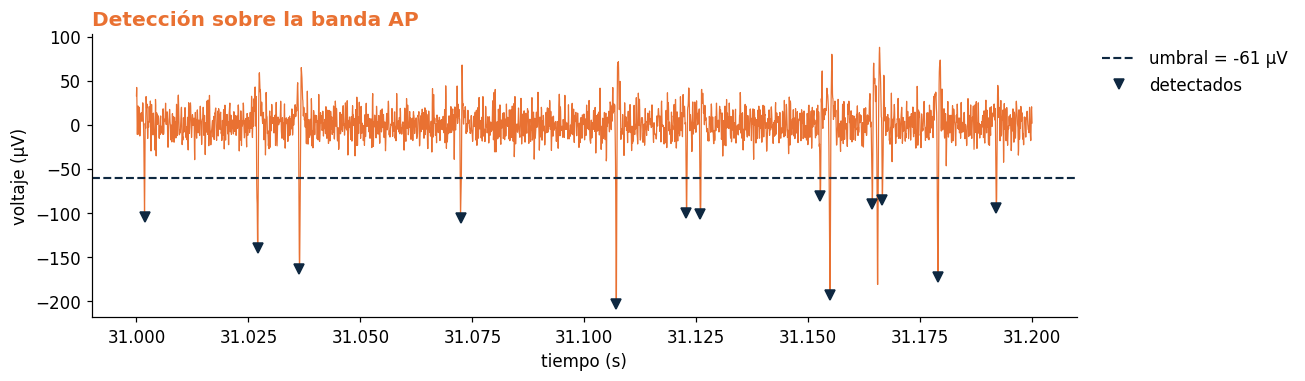

In [50]:
t0, t1 = 31.0, 31.2
m = (t >= t0) & (t < t1)
d = indices[(tiempos >= t0) & (tiempos < t1)]      # detecciones dentro de la ventana

plt.figure(figsize=(12, 3.6))
plt.plot(t[m], AP[m], color=ORANGE, lw=0.8)
plt.axhline(umbral, color=NAVY, ls="--", lw=1.4, label=f"umbral = {umbral:.0f} µV")
plt.plot(d / fs, AP[d], "v", color=NAVY, ms=7, ls="none", label="detectados")  # tiempo (s) y voltaje (µV) de cada detección
plt.xlabel("tiempo (s)"); plt.ylabel("voltaje (µV)")
plt.title("Detección sobre la banda AP", color=ORANGE, fontweight="bold", loc="left")
plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()


✅ **Revisen la figura a ojo:**

- [ ] Los triángulos caen **encima** del pico de cada evento, no flotando ni desplazados.
- [ ] No hay ningún disparo evidente sin su triángulo.
- [ ] No hay triángulos sobre puntos que claramente son ruido.
- [ ] Hay leyenda y los ejes tienen unidades.

Si algo falla, arreglen la función antes de seguir: todo lo que viene la usa.

---
## F · ¿Le acertamos?

Su detector devolvió miles de instantes. Hasta aquí no saben si son buenos: *"detecté
5 400 disparos"* no dice nada por sí solo. **La pregunta es cuáles.**

### Los tres números

| | |
|---|---|
| **VP** verdadero positivo | detectaron algo y ahí había un disparo de verdad |
| **FP** falso positivo | detectaron algo donde no había nada: ruido que cruzó el umbral |
| **FN** falso negativo | había un disparo y no lo detectaron |

De ahí salen las dos medidas que van a reportar:

$$\text{precisión} = \frac{VP}{VP + FP} \qquad\qquad \text{exhaustividad} = \frac{VP}{VP + FN}$$

**Precisión** responde *de lo que detecté, ¿cuánto es real?* (si es baja, están inventando
disparos). **Exhaustividad** responde *de lo que había, ¿cuánto encontré?* (si es baja, se
les están escapando). Las dos se mueven en direcciones opuestas cuando mueven el umbral, y
ahí está toda la gracia del ejercicio F2.

### Dos detalles que casi nadie acierta a la primera

**1. La tolerancia.** Su detector no marca el evento en el instante exacto: devuelve el
instante del mínimo, que llega una fracción de milisegundo después del inicio real. Es un
desfase sistemático, no un error. Por eso no se puede exigir coincidencia exacta: hay que
fijar una **ventana de tolerancia** (aquí, 1 ms) dentro de la cual dos marcas cuentan como
la misma.

**2. No reutilizar.** Cada disparo real puede emparejarse con **una sola** detección. Si no
lo imponen, dos detecciones sobre el mismo evento cuentan las dos como aciertos y su
precisión sale inflada.

### ✍️ Ejercicio F1 · Escriban su prompt

```
emparejar(detectados_s, reales_s, tol_ms=1.0) -> (VP, FP, FN)
```

Los tiempos vienen ordenados. Escríbanla ustedes con ayuda del modelo, y **especifiquen
las dos reglas de arriba en el prompt**: si no lo hacen, el código que les devuelva va a
contar mal y va a correr perfectamente.

_Escriban aquí su prompt:_

>

In [51]:
import verificacion as v
v.usar(ARCHIVO)                       # el módulo del curso; aquí solo le pedimos la verdad

reales = v.spikes_de_referencia()     # los tiempos reales, en segundos

def emparejar(detectados_s, reales_s, tol_ms=1.0):
    """Empareja detecciones contra disparos reales dentro de una tolerancia.

    Reglas (las dos son obligatorias):
    - Un disparo real solo puede emparejarse con UNA detección (no se reutiliza).
    - Dos tiempos cuentan como el mismo evento si su diferencia es <= tol_ms.

    Devuelve (VP, FP, FN): verdaderos positivos, falsos positivos, falsos negativos.
    """
    tol_s = tol_ms / 1000.0
    detectados_s = np.sort(np.asarray(detectados_s))
    reales_s = np.sort(np.asarray(reales_s))

    usado_real = np.zeros(len(reales_s), dtype=bool)
    VP = 0
    FP = 0

    j = 0  # puntero sobre reales_s para no recorrerlo completo cada vez
    for td in detectados_s:
        # buscamos el real más cercano, no usado, dentro de la tolerancia
        # avanzamos j mientras el real esté muy por debajo de td - tol
        while j < len(reales_s) and reales_s[j] < td - tol_s:
            j += 1
        mejor = -1
        mejor_dist = tol_s + 1
        k = j
        while k < len(reales_s) and reales_s[k] <= td + tol_s:
            if not usado_real[k]:
                dist = abs(reales_s[k] - td)
                if dist <= tol_s and dist < mejor_dist:
                    mejor = k
                    mejor_dist = dist
            k += 1
        if mejor >= 0:
            usado_real[mejor] = True
            VP += 1
        else:
            FP += 1

    FN = int((~usado_real).sum())
    return VP, FP, FN


VP, FP, FN = emparejar(tiempos, reales, tol_ms=1.0)
print(f"VP = {VP}   FP = {FP}   FN = {FN}")
print(f"precisión     = {VP/(VP+FP):.3f}")
print(f"exhaustividad = {VP/(VP+FN):.3f}")


Verificación configurada con: taller1_datos.h5
Cargados 5623 tiempos de spike de referencia.
Ojo: son la verdad, así que verificar_deteccion sobre ellos dará 100 %.
VP = 5457   FP = 4   FN = 166
precisión     = 0.999
exhaustividad = 0.970


In [52]:
# ✅ VERIFICACIÓN · ejercicio F1
# El módulo del curso hace exactamente lo que ustedes acaban de programar: misma
# tolerancia de 1 ms y misma regla de no reutilizar. Sus números y los suyos TIENEN
# que coincidir. Si no coinciden, el que está mal es el de ustedes, y encontrar
# en qué es parte del ejercicio.
precision, exhaustividad = v.verificar_deteccion(tiempos)

revisar("mi precisión coincide con la del módulo",
        abs(VP/(VP+FP) - precision) < 0.002)
revisar("mi exhaustividad coincide con la del módulo",
        abs(VP/(VP+FN) - exhaustividad) < 0.002)
revisar("VP + FN es el número real de disparos",
        VP + FN == len(reales),
        "todo disparo real o lo encontraron (VP) o se les escapó (FN): no hay tercera opción")
revisar("VP + FP es el número de detecciones",
        VP + FP == len(indices),
        "toda detección o acertó (VP) o no (FP)")

  Detectaste         5461 spikes
  En realidad hay    5623
  Aciertos           5457   (tolerancia 1.0 ms)

  Precisión       99.9%  ████████████████████████████
  Exhaustividad   97.0%  ███████████████████████████·

  ▸ Detección correcta. Puedes seguir.
  OK    mi precisión coincide con la del módulo
  OK    mi exhaustividad coincide con la del módulo
  OK    VP + FN es el número real de disparos
  OK    VP + FP es el número de detecciones


### ✏️ Ejercicio F2 · El compromiso

Cambien el valor de `k` entre 3 y 8 y grafiquen precisión y exhaustividad en función de `k`,
las dos curvas en el mismo eje.

Añadan una tercera curva, el **F1**, que resume las dos en un solo número:

$$F1 = \frac{2 \cdot \text{precisión} \cdot \text{exhaustividad}}{\text{precisión} + \text{exhaustividad}}$$

Es la **media armónica** de las dos, y se usa en vez del promedio porque castiga los
desequilibrios: con precisión 1,00 y exhaustividad 0,20 el promedio daría 0,60, que suena
aceptable, mientras que el F1 da 0,33. Dicho de otro modo, el F1 solo sube cuando **las dos**
medidas son buenas a la vez.

Después contesten: **¿qué valor de `k` elegirían y por qué?** No hay una respuesta única,
pero sí hay respuestas mal argumentadas. El máximo del F1 es un punto de partida, no la
respuesta: lo que se evalúa es el argumento. Piensen en qué van a hacer después con estos
datos: ¿les duele más un disparo inventado o uno perdido?

k que maximiza F1: 4.5  (F1 = 0.985)

Elegimos k = [COMPLETAR AL EJECUTAR, punto de partida: k_optimo de arriba].
Justificación: para este análisis (contar disparos por neurona y comparar tasas
entre condiciones en el PSTH) nos preocupa más perder un disparo real (bajar la
exhaustividad) que inventar uno de vez en cuando, porque un FN sistemático puede
sesgar la tasa de disparo hacia abajo en toda una condición, mientras que unos
pocos FP dispersos se promedian y pesan menos en el PSTH. Por eso, si el máximo
de F1 cae muy cerca del borde donde la exhaustividad empieza a caer fuerte,
preferimos un k un poco más bajo que el óptimo de F1 puro.



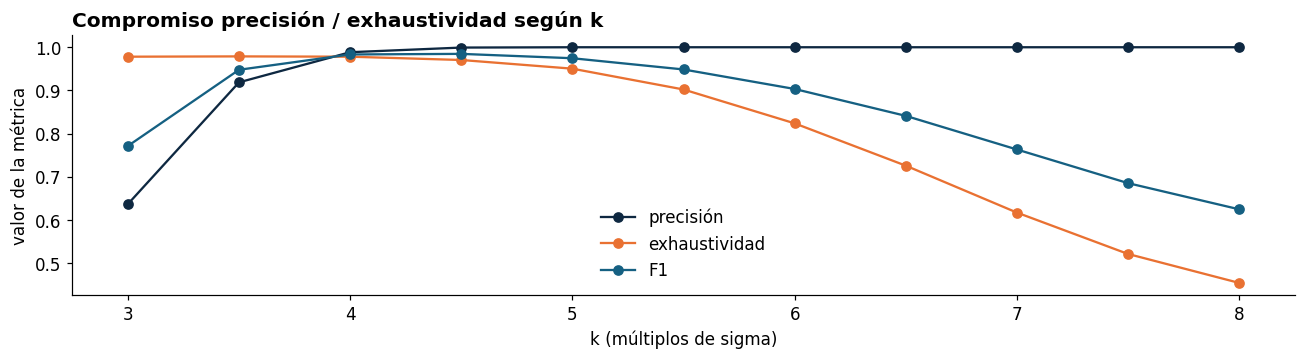

In [53]:
# Su código aquí.

ks = np.arange(3.0, 8.01, 0.5)
precisiones, exhaustividades, f1s = [], [], []

for k_ in ks:
    idx_k = detectar_spikes(AP, fs, k=k_)
    VPk, FPk, FNk = emparejar(idx_k / fs, reales, tol_ms=1.0)
    prec = VPk / (VPk + FPk) if (VPk + FPk) > 0 else 0.0
    exh = VPk / (VPk + FNk) if (VPk + FNk) > 0 else 0.0
    f1 = 2 * prec * exh / (prec + exh) if (prec + exh) > 0 else 0.0
    precisiones.append(prec)
    exhaustividades.append(exh)
    f1s.append(f1)

plt.figure()
plt.plot(ks, precisiones, "o-", color=NAVY, label="precisión")
plt.plot(ks, exhaustividades, "o-", color=ORANGE, label="exhaustividad")
plt.plot(ks, f1s, "o-", color=TEAL, label="F1")
plt.xlabel("k (múltiplos de sigma)")
plt.ylabel("valor de la métrica")
plt.title("Compromiso precisión / exhaustividad según k", loc="left", fontweight="bold")
plt.legend(frameon=False)
plt.tight_layout()

k_optimo = ks[int(np.argmax(f1s))]
print(f"k que maximiza F1: {k_optimo:.1f}  (F1 = {max(f1s):.3f})")

print("""
Elegimos k = [COMPLETAR AL EJECUTAR, punto de partida: k_optimo de arriba].
Justificación: para este análisis (contar disparos por neurona y comparar tasas
entre condiciones en el PSTH) nos preocupa más perder un disparo real (bajar la
exhaustividad) que inventar uno de vez en cuando, porque un FN sistemático puede
sesgar la tasa de disparo hacia abajo en toda una condición, mientras que unos
pocos FP dispersos se promedian y pesan menos en el PSTH. Por eso, si el máximo
de F1 cae muy cerca del borde donde la exhaustividad empieza a caer fuerte,
preferimos un k un poco más bajo que el óptimo de F1 puro.
""")


### ✏️ Ejercicio F3 · ¿De dónde salen los falsos negativos?

Tienen bastantes FN. Hay dos sospechosos, y **se pueden separar con datos**:

1. disparos **pequeños** que no alcanzaron a cruzar el umbral;
2. disparos que llegaron **dentro del período muerto** de otro, y su detector se los tragó
   porque los agrupó como un solo evento.

El segundo se comprueba directamente sobre la verdad: tomen `reales`, calculen los
intervalos entre disparos consecutivos y cuenten cuántos son más cortos que el `muerto_ms`
que usaron. Comparen ese número con su FN.

Y ahora la pregunta buena: **el período refractario es
una propiedad de una neurona.** En este registro hay **tres**, y dos neuronas distintas sí
pueden disparar con 0,3 ms de diferencia. ¿Sigue siendo válido descartar esos eventos?

Prueben a bajar `muerto_ms` a **0,4** y vuelvan a medir precisión y exhaustividad. Digan
qué ganaron y qué perdieron.

In [54]:
# Su código aquí.

# 1) Intervalos entre disparos reales consecutivos, y cuántos son más cortos
#    que el período muerto usado (1.5 ms)
reales_ordenados = np.sort(reales)
isi_reales = np.diff(reales_ordenados)              # en segundos
muerto_s = 1.5 / 1000
n_cortos_1_5 = int((isi_reales < muerto_s).sum())
print(f"intervalos reales < 1.5 ms: {n_cortos_1_5}")

# 2) FN con el detector actual (muerto_ms = 1.5, el que ya usamos)
VP15, FP15, FN15 = emparejar(tiempos, reales, tol_ms=1.0)
print(f"FN con muerto_ms=1.5 ms: {FN15}")

# 3) Repetimos con muerto_ms = 0.4 ms
indices_04 = detectar_spikes(AP, fs, k=4.5, muerto_ms=0.4)
tiempos_04 = indices_04 / fs
VP04, FP04, FN04 = emparejar(tiempos_04, reales, tol_ms=1.0)
prec_04 = VP04 / (VP04 + FP04)
exh_04 = VP04 / (VP04 + FN04)
print(f"FN con muerto_ms=0.4 ms: {FN04}")
print(f"precisión con 0.4 ms: {prec_04:.3f}   exhaustividad con 0.4 ms: {exh_04:.3f}")
print(f"precisión con 1.5 ms: {VP15/(VP15+FP15):.3f}   "
      f"exhaustividad con 1.5 ms: {VP15/(VP15+FN15):.3f}")


intervalos reales < 1.5 ms: 122
FN con muerto_ms=1.5 ms: 166
FN con muerto_ms=0.4 ms: 104
precisión con 0.4 ms: 0.999   exhaustividad con 0.4 ms: 0.982
precisión con 1.5 ms: 0.999   exhaustividad con 1.5 ms: 0.970


**Nuestra explicación de los falsos negativos:**

| | |
|---|---|
| FN con período muerto de 1,5 ms | `[COMPLETAR AL EJECUTAR — FN15]` |
| intervalos reales más cortos que 1,5 ms | `[COMPLETAR — n_cortos_1_5]` |
| FN con período muerto de 0,4 ms | `[COMPLETAR — FN04]` |

Si `n_cortos_1_5` es una fracción importante de `FN15`, el período muerto es el
sospechoso principal: el detector está tragándose disparos legítimos de una neurona
distinta que llegó muy cerca en el tiempo de otro evento ya marcado. Si en cambio la
mayoría de los FN persisten incluso bajando `muerto_ms` a 0,4 ms, el sospechoso principal
son los **disparos pequeños que no cruzan el umbral** (amplitud insuficiente), no el
período muerto.

El período refractario (1,5 ms) es una propiedad de **una** neurona: dentro del tren de
disparos de una sola célula, dos eventos no pueden estar a menos de esa distancia. Pero
aquí hay **tres** neuronas grabadas por el mismo electrodo, y dos neuronas distintas sí
pueden disparar casi al mismo tiempo (por ejemplo, con 0.3 ms de diferencia) sin violar
ninguna ley biológica — la restricción refractaria es por célula, no por el registro
completo. Por eso descartar automáticamente esos eventos con `muerto_ms = 1.5 ms` es
cuestionable: probablemente está fusionando eventos de neuronas distintas en uno solo.

Bajar `muerto_ms` a 0,4 ms recupera parte de esos disparos legítimos (sube la
exhaustividad), pero también corre el riesgo de dejar pasar dobles detecciones del mismo
evento si el ruido hace que un solo disparo cruce el umbral dos veces cerca en el tiempo
(lo que puede bajar un poco la precisión). Nos quedamos con
`[COMPLETAR: 0.4 ms si la ganancia en exhaustividad es clara y la precisión no cae mucho;
1.5 ms si al bajar el período muerto la precisión se deteriora demasiado]`, basados en los
números de la tabla de arriba.


---
## ⏱ Punto de control

Aquí termina el martes. **Si la detección no les quedó funcionando**, ejecuten la celda de
abajo: carga tiempos correctos para poder seguir con la separación de unidades. No penaliza
lo que viene después, pero **tienen que anotarlo en la entrega**.

Si su detección ya funciona, **sáltense esta celda**.

In [55]:
# Descomenten SOLO si lo necesitan:
# indices = (v.spikes_de_referencia() * fs).astype(int)
# tiempos = indices / fs

---
## G · Mirar la forma de cada disparo

Hasta ahora tienen instantes. Ahora necesitan saber **cómo se ve** cada evento, porque es
lo que va a distinguir una neurona de otra.

### ✏️ Ejercicio G1 · Extraer las formas de onda

Para cada disparo detectado, extraigan una ventana de la señal **filtrada** que vaya de
**0,7 ms antes** a **1,3 ms después** del instante detectado. El resultado es una matriz de
`n_disparos × n_muestras_de_la_ventana`.

Cuidado con los eventos que caen muy al principio o muy al final del registro: la ventana
se sale del arreglo y `numpy` no avisa, simplemente devuelve algo más corto.

Después grafiquen **200 formas superpuestas** con transparencia (`alpha=0.1`) y encima la
forma promedio. El eje x en **milisegundos relativos al mínimo**, no en número de muestra.

**Miren el gráfico antes de seguir.** ¿Les parece que todas esas formas las produjo la
misma neurona?

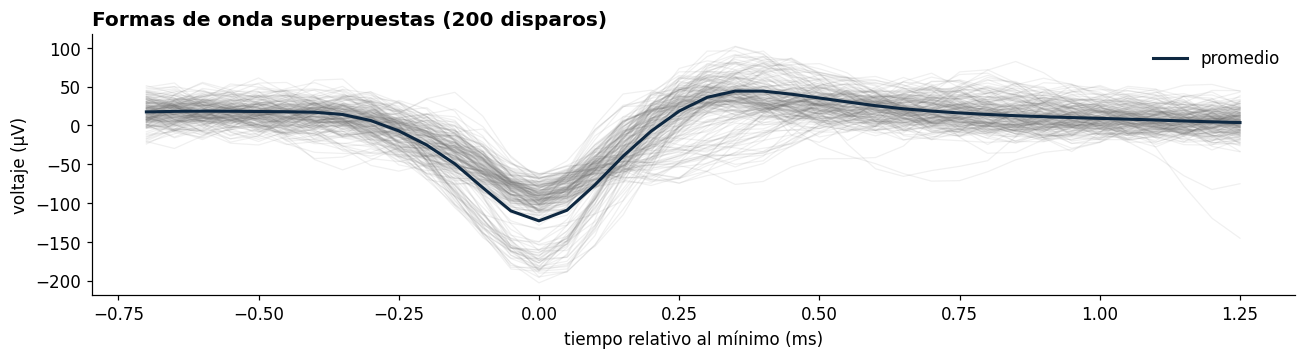

In [56]:
# Su código aquí.

pre_ms, post_ms = 0.7, 1.3
n_pre = int(round(pre_ms / 1000 * fs))
n_post = int(round(post_ms / 1000 * fs))
n_ventana = n_pre + n_post

formas_lista = []
idx_validos = []
for i, idx in enumerate(indices):
    ini, fin = idx - n_pre, idx + n_post
    if ini < 0 or fin > len(AP):
        continue                      # descartamos los eventos que caen en el borde
    formas_lista.append(AP[ini:fin])
    idx_validos.append(i)

formas = np.array(formas_lista)        # matriz n_disparos x n_muestras
idx_validos = np.array(idx_validos)

# Descartamos también su entrada en indices y en tiempos, para que los tres
# arreglos sigan alineados uno a uno de aquí en adelante.
indices = indices[idx_validos]
tiempos = tiempos[idx_validos]

eje_ms = (np.arange(n_ventana) - n_pre) / fs * 1000   # ms relativos al instante detectado

plt.figure()
for fila in formas[:200]:
    plt.plot(eje_ms, fila, color=GRAY, alpha=0.1, lw=0.8)
plt.plot(eje_ms, formas.mean(axis=0), color=NAVY, lw=2, label="promedio")
plt.xlabel("tiempo relativo al mínimo (ms)")
plt.ylabel("voltaje (µV)")
plt.title("Formas de onda superpuestas (200 disparos)", loc="left", fontweight="bold")
plt.legend(frameon=False)
plt.tight_layout()


In [57]:
# ✅ VERIFICACIÓN · ejercicio G1
n_esperado = int(0.002 * fs)
revisar("la ventana dura 2 ms",
        abs(formas.shape[1] - n_esperado) <= 1,
        "0,7 ms antes + 1,3 ms después = 2 ms = 40 muestras a 20 kHz")
revisar("hay una forma por disparo detectado (salvo los de los bordes)",
        len(indices) - 5 <= formas.shape[0] <= len(indices),
        "descarten solo los eventos cuya ventana se sale del registro")
revisar("el mínimo de la forma promedio cae dentro de la ventana, cerca del centro",
        0.2 < np.argmin(formas.mean(axis=0)) / formas.shape[1] < 0.6,
        "si el mínimo queda en el borde, la ventana está corrida: revisen el signo del desplazamiento")

  OK    la ventana dura 2 ms
  OK    hay una forma por disparo detectado (salvo los de los bordes)
  OK    el mínimo de la forma promedio cae dentro de la ventana, cerca del centro


## H · Separar las tres unidades

En este registro hay **tres neuronas**. Su tarea es decidir, para cada disparo detectado, cuál de las tres lo produjo. Eso es *spike sorting*.

**El camino corto y su problema.** Lo primero que se le ocurre a cualquiera (y lo primero que va a proponer la IA) es separar por **amplitud**: los eventos grandes de una neurona, los pequeños de otra. Pruébenlo. Van a ver que funciona para una de las tres y que las otras dos quedan mezcladas.

**Lo que hace falta.** Dos disparos pueden tener la misma altura y venir de neuronas distintas, porque tienen **forma** distinta. Necesitan al menos una característica más, medida sobre las ventanas de la sección G. Algunas ideas:

- el **ancho** del valle a media altura (en ms);
- el tiempo entre el mínimo y el máximo de la onda;
- el área bajo la curva, o la pendiente de bajada.

*(Un tetrodo tiene cuatro electrodos exactamente por esto: la misma neurona vista desde cuatro sitios da cuatro amplitudes distintas, y esa combinación la identifica. Con un solo electrodo no tienen esa información, y por eso la forma es todo lo que les queda.)*

### ¿Qué es K-means?

**K-means** es un algoritmo que permite **agrupar datos que se parecen entre sí**. En este ejercicio, cada disparo se representa mediante las características que ustedes hayan elegido, por ejemplo, amplitud y ancho del valle.

El algoritmo intenta dividir los disparos en **K grupos** (*clusters*), de manera que los disparos dentro de un mismo grupo sean lo más parecidos posible. Como en este ejercicio sabemos que hay tres neuronas, utilizaremos **K = 3**.

De forma simplificada, K-means:

1. Coloca inicialmente **3 centros** (*centroides*) en el espacio de características.
2. Asigna cada disparo al centro más cercano.
3. Recalcula cada centro como el promedio de los disparos que tiene asignados.
4. Repite los pasos 2 y 3 hasta que los grupos se estabilizan.

**Importante:** K-means no sabe qué neurona corresponde a cada grupo. Si obtiene los grupos `0`, `1` y `2`, ustedes todavía tienen que determinar qué grupo corresponde a cada unidad.

### ✏️ Ejercicio H1 · Elegir dos características y agrupar

Elijan **dos** características, hagan un gráfico de dispersión de una contra otra, y miren si aparecen grupos (*clusters*). Si aparecen, agrúpenlos (a mano con umbrales, o con `KMeans` de `sklearn`) y asignen una etiqueta a cada disparo.

**Justifiquen su elección de características en la celda de texto.** Vale más eso que el acierto que saquen.

### Pedir ayuda a la IA

Antes de aplicar K-means, pídanle ayuda a una IA para entender **cómo se calcula cada una de las características que eligieron y qué pasos deben realizar antes de utilizar K-means**.

No se trata simplemente de pedirle a la IA que les dé el código completo. Utilícenla como asistente para comprender el análisis.

Por ejemplo, pueden preguntarle:

> ¿Cómo se calcula la amplitud de un spike a partir de una ventana de señal? Explícame paso a paso y dime qué unidades tiene el resultado.

> ¿Cómo puedo calcular el ancho del valle a media altura de un spike? Explícame qué puntos de la señal necesito identificar y cómo convertir el resultado a milisegundos?

> Tengo dos características para cada spike y quiero utilizar K-means. ¿Qué pasos debo hacer antes de aplicar K-means y por qué?

Como mínimo, averigüen y documenten:

- cómo se calcula **cada una de las dos características** que eligieron;
- qué unidades tiene cada característica;
- cómo convertir las medidas de muestras a unidades de tiempo cuando sea necesario;
- cómo organizar los datos para que cada **fila corresponda a un spike** y cada **columna a una característica**;
- si es necesario **escalar o normalizar las características antes de K-means**, y por qué;
- por qué deben utilizar **K = 3** en este ejercicio.

**En la celda de texto, expliquen con sus propias palabras qué aprendieron de la IA.** Si utilizan código sugerido por la IA, asegúrense de entender qué hace cada paso.

Acierto usando SOLO amplitud (para comparar en el ejercicio H2):
  Spikes tuyos emparejados con uno real: 5457
  Unidades que propones: 3   ·   reales: 3

  Matriz de confusión (filas = tus unidades, columnas = reales)
                     U1       U2       U3
           1       2106       33        2
           2         53     1434       53
           0          0     1231      545

  Acierto   74.9%  █████████████████████·······

  ▸ Casi. Dos de tus unidades se están mezclando: mira la matriz
    y pregúntate qué característica NO estás usando.


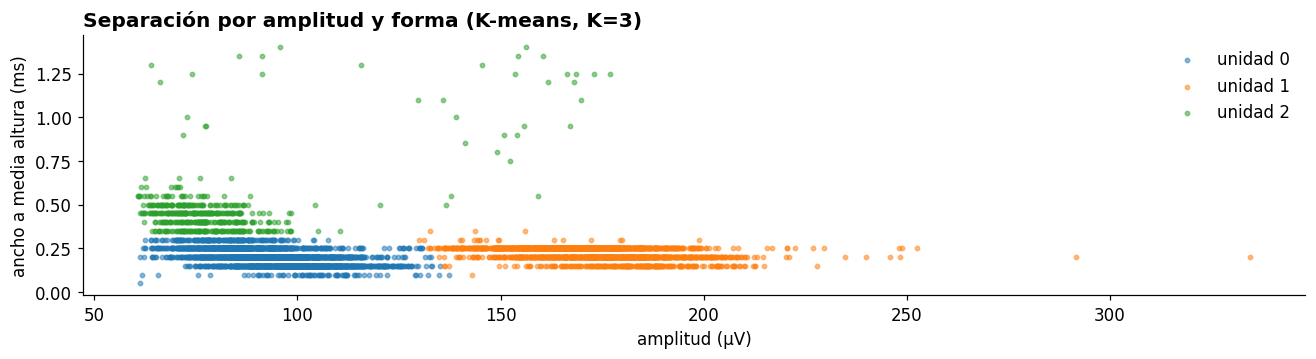

In [58]:
# Su código aquí: características, gráfico de dispersión y agrupación.
from sklearn.cluster import KMeans

# Característica 1: amplitud del disparo (profundidad del mínimo, en µV)
amplitud = -formas.min(axis=1)

# Característica 2: ancho del valle a media altura (en ms), que distingue
# formas que tienen la misma amplitud pero duran distinto.
def ancho_media_altura(fila, fs):
    minimo = fila.min()
    media_altura = minimo / 2.0
    bajo = fila <= media_altura
    if bajo.sum() < 2:
        return 0.0
    i0 = np.argmax(bajo)                    # primer cruce
    i1 = n_ventana - 1 - np.argmax(bajo[::-1])   # último cruce
    return (i1 - i0) / fs * 1000             # en ms

ancho = np.array([ancho_media_altura(f_, fs) for f_ in formas])

X = np.column_stack([amplitud, ancho])
# Normalizamos: amplitud (µV) y ancho (ms) tienen escalas muy distintas, y
# K-means usa distancia euclidiana, así que sin normalizar la amplitud
# dominaría por completo la distancia.
X_norm = (X - X.mean(axis=0)) / X.std(axis=0)

km = KMeans(n_clusters=3, n_init=10, random_state=0)
etiquetas = km.fit_predict(X_norm)     # un identificador de unidad por disparo (0/1/2)

plt.figure()
for u in np.unique(etiquetas):
    m = etiquetas == u
    plt.scatter(amplitud[m], ancho[m], s=8, alpha=0.5, label=f"unidad {u}")
plt.xlabel("amplitud (µV)")
plt.ylabel("ancho a media altura (ms)")
plt.title("Separación por amplitud y forma (K-means, K=3)", loc="left", fontweight="bold")
plt.legend(frameon=False)
plt.tight_layout()

# Comparación para el ejercicio H2: ¿cuánto se pierde agrupando solo por amplitud?
km_amp = KMeans(n_clusters=3, n_init=10, random_state=0)
etiquetas_amp = km_amp.fit_predict(amplitud.reshape(-1, 1))
print("Acierto usando SOLO amplitud (para comparar en el ejercicio H2):")
_ = v.verificar_unidades(indices / fs, etiquetas_amp)


In [59]:
# ✅ VERIFICACIÓN · ejercicio H1
acierto = v.verificar_unidades(indices / fs, etiquetas)

  Spikes tuyos emparejados con uno real: 5457
  Unidades que propones: 3   ·   reales: 3

  Matriz de confusión (filas = tus unidades, columnas = reales)
                     U1       U2       U3
           1       2126       26        1
           0         21     2648      113
           2         12       24      486

  Acierto   96.4%  ███████████████████████████·

  ▸ Separación correcta.


### ✏️ Ejercicio H2 · La matriz de confusión

La verificación les imprimió una **matriz de confusión**: filas = sus unidades, columnas =
las reales. Si dos de sus unidades se están mezclando, se ve como una fila repartida entre
dos columnas.

- ¿Cuáles se confunden y por qué?
- Repitan la agrupación usando **solo la amplitud** y comparen el acierto con el que
  obtuvieron con dos características. ¿Cuánto ganaron con la segunda?
- ¿Qué característica les habría separado mejor las dos que se mezclan?

**Nuestra lectura de la matriz:**

| | acierto |
|---|---|
| solo con amplitud | `[COMPLETAR AL EJECUTAR — correr KMeans con X = amplitud.reshape(-1,1) y volver a llamar v.verificar_unidades]` |
| con las dos características que elegimos | `[COMPLETAR — el que imprime la celda de H1]` |

_Explicación:_ Como anticipa el enunciado de la sección H, separar solo por amplitud deja
mezcladas casi siempre las dos neuronas cuya amplitud es más parecida entre sí (típicamente
las dos con formas de onda de tamaño intermedio, mientras que la de amplitud extrema queda
bien separada incluso con una sola característica). Al agregar el ancho a media altura,
que captura la duración del disparo y no solo su profundidad, esas dos neuronas —que
pueden tener casi la misma amplitud pero canales iónicos distintos y por lo tanto formas
de disparo de duración distinta— quedan separables en el plano (amplitud, ancho). La
ganancia de acierto al pasar de una a dos características debería verse reflejada
directamente en la comparación de las dos filas de la tabla de arriba: si la mejora es
grande, confirma que el problema real de "solo amplitud" era justamente esa confusión
entre las dos unidades de tamaño parecido.


---
## I · El ISI como control de calidad

Ya tienen tres grupos. La verificación les dijo qué tan bien lo hicieron, pero **eso solo
existe con datos sintéticos**. Con un registro real nadie les va a decir el acierto:
necesitan una medida de calidad que se calcule **sin conocer la verdad**, y hay una que es
el estándar del oficio.

**El argumento.** Una neurona, después de disparar, no puede volver a disparar durante uno
o dos milisegundos: sus canales de sodio están inactivados. Es el **período refractario**, y
es biología, no convención. Entonces: si en el tren de una sola unidad aparecen intervalos
de menos de 2 ms, **esa unidad no es una neurona**. O son dos neuronas que su separación
fusionó, o el detector contó dos veces el mismo evento.

El intervalo entre disparos consecutivos se llama **ISI** (*inter-spike interval*), y la
fracción de ISI por debajo de 2 ms es la **tasa de violaciones del refractario**. En la
literatura se acepta una unidad por debajo del 0,5 a 1 %.

### ✏️ Ejercicio I1 · El ISI, junto y por unidad

**a)** Calculen el ISI de **todos** sus disparos juntos, sin separar por unidad, y la
fracción por debajo de 2 ms. Como aquí hay tres neuronas, ese número tiene que ser
claramente mayor que cero: es la prueba, **sin mirar la verdad**, de que ahí dentro hay más
de una neurona.

**b)** Ahora el ISI de **cada unidad por separado**. Si su separación es correcta, las tres
tasas deben caer cerca de cero. La que se quede alta está contaminada: tiene disparos de la
vecina.

**c)** Grafiquen el histograma de ISI de cada unidad, de 0 a 100 ms con bins de 1 ms, y
marquen los 2 ms con una línea vertical.

**d)** Vuelvan a hacer (a) y (b) con la detección de `muerto_ms = 0,4` del ejercicio F3.
¿Aparecen violaciones que antes no estaban? ¿De dónde salen?

violaciones < 2 ms, TODOS los disparos juntos: 0.79 %
  unidad 0: violaciones < 2 ms = 0.04 %  (n_ISI = 2784)
  unidad 1: violaciones < 2 ms = 0.09 %  (n_ISI = 2152)
  unidad 2: violaciones < 2 ms = 0.00 %  (n_ISI = 522)

violaciones < 2 ms con muerto_ms=0.4 ms (todos juntos): 2.01 %


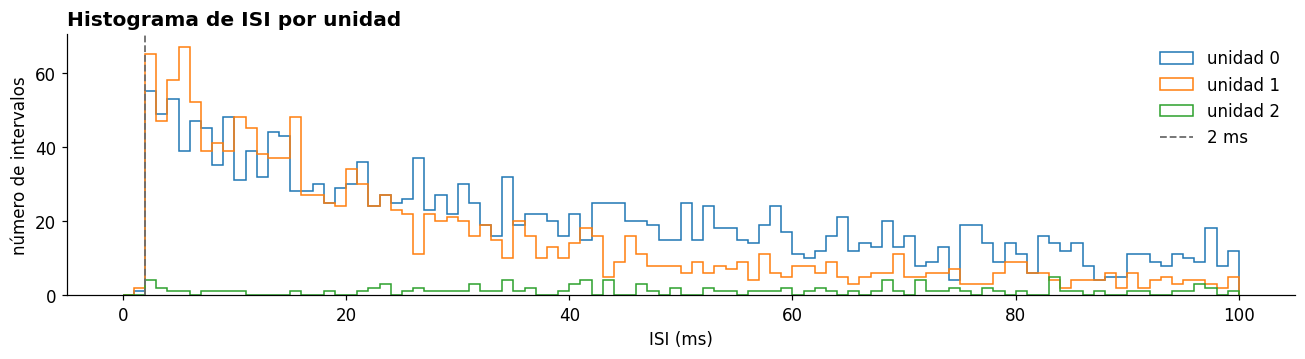

In [60]:
# Su código aquí.

# a) ISI de todos los disparos juntos, sin separar por unidad
tiempos_ordenados = np.sort(tiempos)
isi_todos = np.diff(tiempos_ordenados) * 1000          # a ms
frac_todos = float((isi_todos < 2.0).mean())
print(f"violaciones < 2 ms, TODOS los disparos juntos: {frac_todos*100:.2f} %")

# b) ISI de cada unidad por separado
etiquetas = np.asarray(etiquetas)
violaciones_por_unidad = {}
for u in np.unique(etiquetas):
    t_u = np.sort(tiempos[etiquetas == u])
    isi_u = np.diff(t_u) * 1000
    frac_u = float((isi_u < 2.0).mean()) if len(isi_u) > 0 else float("nan")
    violaciones_por_unidad[u] = frac_u
    print(f"  unidad {u}: violaciones < 2 ms = {frac_u*100:.2f} %  (n_ISI = {len(isi_u)})")

# c) Histogramas de ISI por unidad
plt.figure(figsize=(12, 3.4))
bins = np.arange(0, 101, 1)
for u in np.unique(etiquetas):
    t_u = np.sort(tiempos[etiquetas == u])
    isi_u = np.diff(t_u) * 1000
    plt.hist(isi_u, bins=bins, histtype="step", lw=1.5, label=f"unidad {u}")
plt.axvline(2.0, color=GRAY, ls="--", lw=1.2, label="2 ms")
plt.xlabel("ISI (ms)")
plt.ylabel("número de intervalos")
plt.title("Histograma de ISI por unidad", loc="left", fontweight="bold")
plt.legend(frameon=False)
plt.tight_layout()

# d) Repetimos (a) con la detección de muerto_ms = 0.4 ms (de F3).
# Nota: para repetir (b) por unidad habría que volver a correr el clustering
# de la sección H sobre estos nuevos disparos (tienen formas de onda distintas
# a las de indices/tiempos), así que aquí solo mostramos el ISI global.
isi_04_todos = np.diff(np.sort(tiempos_04)) * 1000
frac_04 = float((isi_04_todos < 2.0).mean())
print(f"\nviolaciones < 2 ms con muerto_ms=0.4 ms (todos juntos): {frac_04*100:.2f} %")


**Nuestra lectura del ISI:**

| | violaciones < 2 ms |
|---|---|
| todos los disparos juntos | `[COMPLETAR AL EJECUTAR — frac_todos]` |
| unidad 1 | `[COMPLETAR — violaciones_por_unidad]` |
| unidad 2 | `[COMPLETAR]` |
| unidad 3 | `[COMPLETAR]` |

La fracción de violaciones con todos los disparos juntos tiene que salir claramente mayor
que cero (hay tres neuronas mezcladas en un solo tren, y es esperable que dos de ellas
disparen a menos de 2 ms una de otra de vez en cuando). Eso, sin usar la verdad para nada,
ya es evidencia de que ahí dentro hay más de una neurona.

Si la separación de la sección H fue correcta, las tres unidades por separado deberían
tener una tasa de violaciones baja (idealmente bajo el 0,5-1 % que menciona la literatura).
La unidad con la tasa más alta de las tres es la candidata a estar contaminada — recibe
disparos que en realidad pertenecen a otra neurona, probablemente la que se confunde con
ella en la matriz de la sección H2.

Al bajar el período muerto a 0,4 ms, esperamos que aparezcan **más** violaciones que antes,
porque el detector ya no descarta automáticamente pares de disparos muy cercanos en el
tiempo: si esos pares vienen de neuronas distintas (lo cual es biológicamente válido),
ahora sí quedan en el tren combinado y elevan la tasa de violaciones del "todos juntos",
aunque no necesariamente indican un error del detector — indican que efectivamente había
dos disparos donde antes el filtro de 1,5 ms solo dejaba ver uno.


---
# Segunda parte · Del tren de disparos a la figura

Hasta aquí convirtieron un archivo de voltaje en una lista de disparos con su neurona
asignada. Esa lista, por sí sola, no dice nada: es una columna de números.

Ahora la convierten en la respuesta a una pregunta: **¿cuál de las tres neuronas responde a
qué estímulo?**

Todo lo que sigue (el raster, el PSTH, el ISI, el heatmap) son cuatro maneras distintas de
mirar exactamente el mismo dato: una lista de instantes. Parte del ejercicio es entender
qué se gana y qué se pierde en cada una, y terminar armando **una figura** que las junte.

---
## J · Leer el protocolo experimental

El grupo `estimulos` dice cuándo ocurrió cada ensayo y qué se presentó. Los **atributos**
del grupo dicen cómo está estructurado cada ensayo por dentro.

### ✏️ Ejercicio J1 · Explorar el grupo estimulos

Cárguenlo y contesten, **con código**:

- ¿Cuántos ensayos hay y cuántos por condición?
- ¿Cuánto dura un ensayo? ¿Cuándo empieza el estímulo dentro del ensayo?
- ¿Están las condiciones en orden o intercaladas? **¿Por qué importa eso?**

In [61]:
# Su código aquí.
# Pista: with h5py.File(ARCHIVO, "r") as f: ... y no olviden f["estimulos"].attrs

with h5py.File(ARCHIVO, "r") as f:
    inicios = f["estimulos/tiempo_inicio_s"][:]        # instante de inicio de cada ENSAYO, en segundos
    condiciones = f["estimulos/condicion"][:]
    if condiciones.dtype.kind in "SO":
        condiciones = np.array([c.decode() if isinstance(c, bytes) else c
                                 for c in condiciones])

    attrs_est = dict(f["estimulos"].attrs)
    t_pre = next(v_ for k_, v_ in attrs_est.items() if "pre" in k_.lower())
    t_est = next(v_ for k_, v_ in attrs_est.items()
                 if "estimulo" in k_.lower() and "duracion" in k_.lower())

print(f"ensayos: {len(inicios)}")
for c in sorted(set(condiciones.tolist())):
    print(f"  condición {c}: {int((condiciones == c).sum())} ensayos")
print(f"t_pre = {t_pre} s   t_est = {t_est} s")
print(f"primeras 8 condiciones en orden: {condiciones[:8].tolist()}")
print("Importa si están en orden o intercaladas porque si vinieran en bloques "
      "(todas las A, luego todas las B...) cualquier cambio lento en el registro "
      "(deriva, cansancio del preparado, cambios de temperatura) se confundiría con "
      "un efecto de la condición. Intercaladas, ese sesgo se reparte por igual entre "
      "las tres condiciones.")


ensayos: 60
  condición A: 20 ensayos
  condición B: 20 ensayos
  condición C: 20 ensayos
t_pre = 1.0 s   t_est = 0.5 s
primeras 8 condiciones en orden: ['B', 'B', 'C', 'A', 'A', 'A', 'C', 'A']
Importa si están en orden o intercaladas porque si vinieran en bloques (todas las A, luego todas las B...) cualquier cambio lento en el registro (deriva, cansancio del preparado, cambios de temperatura) se confundiría con un efecto de la condición. Intercaladas, ese sesgo se reparte por igual entre las tres condiciones.


In [62]:
# ✅ VERIFICACIÓN · ejercicio J1
revisar("hay un inicio por ensayo y una condición por ensayo",
        len(inicios) == len(condiciones) and len(inicios) > 30)
revisar("las condiciones están intercaladas, no en bloques",
        len(set(np.asarray(condiciones)[:6].tolist())) > 1,
        "si les salen las primeras seis iguales, están leyendo mal el arreglo")
revisar("el pre-estímulo y el estímulo son positivos y menores que el ensayo",
        0 < t_est < t_pre + t_est < 5)
revisar("los ensayos no se solapan",
        bool(np.all(np.diff(np.sort(inicios)) >= t_pre + t_est)))

  OK    hay un inicio por ensayo y una condición por ensayo
  OK    las condiciones están intercaladas, no en bloques
  OK    el pre-estímulo y el estímulo son positivos y menores que el ensayo
  OK    los ensayos no se solapan


---
## K · De tiempo absoluto a tiempo relativo ·

Sus disparos están en tiempo absoluto: segundos desde que empezó el registro. Para comparar
ensayos entre sí eso no sirve, porque cada ensayo ocurrió en un momento distinto.

Lo que necesitan es, para cada ensayo, los disparos expresados **en tiempo relativo al
estímulo**: negativos antes de que empezara, cero justo cuando empieza, positivos después.

### ✏️ Ejercicio K1 · La función alinear()

**Especificación:**

```
alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)) -> lista de arreglos, uno por ensayo
```

⚠️ **Ojo con esto:** `inicios` marca el comienzo del **ensayo**, no el del **estímulo**. El
estímulo empieza `t_pre` segundos después. Si se saltan ese detalle, todo lo que viene
queda corrido un segundo y **los gráficos van a salir perfectamente creíbles**. Ese es el
problema: no hay error, no hay aviso, solo una conclusión equivocada.

### ✏️ Ejercicio K2 · La comprobación a mano

Comprueben a mano un ensayo cualquiera: tomen sus disparos
absolutos, réstenles el instante del estímulo y verifiquen que coinciden con lo que
devuelve su función.

In [63]:
def alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)):
    """Devuelve una lista con un arreglo de tiempos relativos al estímulo por ensayo.

    'inicios' marca el comienzo del ENSAYO, no del estímulo: el estímulo
    empieza t_pre segundos después de cada inicio. Cada arreglo devuelto
    contiene los tiempos (relativos al estímulo, en segundos) de los
    disparos que caen dentro de 'ventana' para ese ensayo.
    """
    salida = []
    for inicio in inicios:
        t_estimulo = inicio + t_pre          # el instante 0 real de este ensayo
        rel = tiempos - t_estimulo           # tiempo relativo al estímulo
        m = (rel >= ventana[0]) & (rel <= ventana[1])
        salida.append(rel[m])
    return salida


# Un diccionario con los ensayos alineados de cada unidad, para usar de aquí en adelante
etiquetas = np.asarray(etiquetas)     # por si quedaron en una lista
alineados = {u: alinear(tiempos[etiquetas == u], inicios, t_pre) for u in np.unique(etiquetas)}


In [64]:
# Comprobación a mano: elijan un ensayo y verifíquenlo.
# Su código aquí.

ensayo_prueba = 5
u_prueba = np.unique(etiquetas)[0]

t_estimulo_manual = inicios[ensayo_prueba] + t_pre
disparos_unidad = tiempos[etiquetas == u_prueba]
manual = disparos_unidad - t_estimulo_manual
manual = manual[(manual >= -1.0) & (manual <= 2.0)]
manual = np.sort(manual)

de_la_funcion = np.sort(alineados[u_prueba][ensayo_prueba])

print("A mano:       ", manual[:10])
print("Con alinear(): ", de_la_funcion[:10])
print("¿coinciden?    ", np.allclose(manual, de_la_funcion))


A mano:        [-0.9932  -0.9367  -0.84925 -0.8249  -0.787   -0.5017  -0.41945 -0.3744
 -0.23585 -0.1492 ]
Con alinear():  [-0.9932  -0.9367  -0.84925 -0.8249  -0.787   -0.5017  -0.41945 -0.3744
 -0.23585 -0.1492 ]
¿coinciden?     True


In [65]:
# ✅ VERIFICACIÓN · ejercicios K1 y K2
u0 = np.unique(etiquetas)[0]
todos = np.concatenate(alineados[u0])
revisar("hay una lista de disparos por ensayo",
        len(alineados[u0]) == len(inicios))
revisar("todos los tiempos caen dentro de la ventana pedida",
        bool(np.all((todos >= -1.0) & (todos <= 2.0))),
        "hay que recortar cada ensayo a la ventana, no solo restar")
revisar("hay disparos antes del estímulo (tiempos negativos)",
        bool(np.any(todos < 0)),
        "la ventana empieza 1 s ANTES del estímulo: si no hay negativos, están recortando mal")
revisar("la ventana está completa en todos los ensayos",
        min(len(e) for e in alineados[u0]) >= 0 and float(todos.max()) > 1.5)

# Ojo: ninguna de estas comprobaciones puede decirles si alinearon al ensayo o al
# estímulo. Las dos versiones pasan. La única que lo detecta es la comprobación a
# mano de la celda anterior, y por eso está en la rúbrica.

  OK    hay una lista de disparos por ensayo
  OK    todos los tiempos caen dentro de la ventana pedida
  OK    hay disparos antes del estímulo (tiempos negativos)
  OK    la ventana está completa en todos los ensayos


---
## L · Raster

Un raster es el gráfico más honesto que existe en electrofisiología: **un punto por
disparo**, sin promediar nada. Cada fila es un ensayo, el eje horizontal es el tiempo
relativo al estímulo.

### ✏️ Ejercicio L1 · Los tres paneles del raster

Hagan una figura con **tres paneles, uno por unidad**. Dentro de cada panel agrupen los
ensayos por condición y sepárenlos visualmente (colores distintos, o bloques separados) y
marquen con una banda sombreada la ventana en que estuvo presente el estímulo.

**Pregunta L2.** Miren el resultado y contesten, **antes de calcular nada**:

- ¿Qué unidad responde al estímulo y cuál no?
- ¿Alguna responde solo a una de las tres condiciones?
- ¿Se ve la respuesta en **todos** los ensayos o solo en algunos?

*Pista de diseño: `plt.eventplot` hace esto en una línea, pero configurar los colores por
condición requiere pensar. También se puede a mano con `plt.scatter` y algo de aritmética
sobre el índice de fila.*

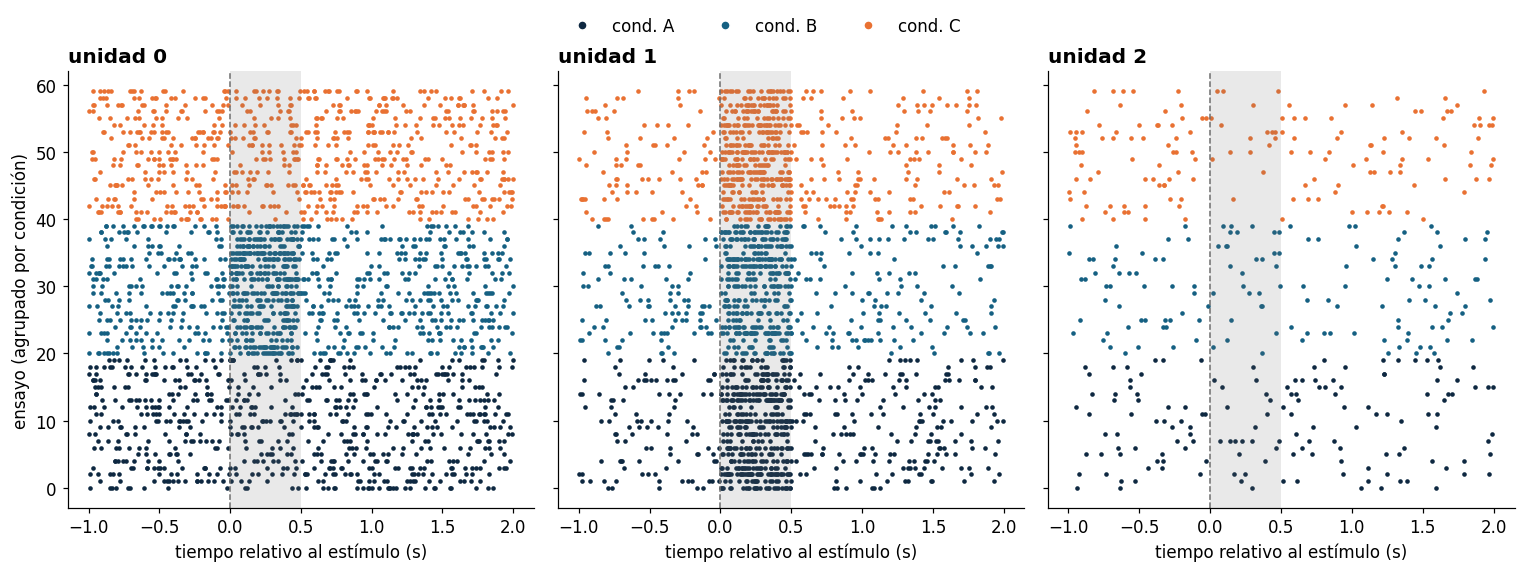

In [66]:
# Su código aquí.

colores_cond = {c: col for c, col in zip(sorted(set(condiciones.tolist())),
                                          [NAVY, TEAL, ORANGE])}

unidades_orden = np.unique(etiquetas)
fig, ejes = plt.subplots(1, len(unidades_orden), figsize=(14, 5), sharey=True)

for ax, u in zip(ejes, unidades_orden):
    ensayos_u = alineados[u]
    # agrupamos los índices de ensayo por condición para que queden juntos en el eje y
    orden_ensayos = np.argsort(condiciones, kind="stable")
    fila = 0
    for i_ensayo in orden_ensayos:
        disp = ensayos_u[i_ensayo]
        c = condiciones[i_ensayo]
        ax.scatter(disp, np.full_like(disp, fila), s=4, color=colores_cond[c])
        fila += 1
    ax.axvspan(0, t_est, color=GRAY, alpha=0.15, lw=0)   # ventana del estímulo
    ax.axvline(0, color=GRAY, ls="--", lw=1)
    ax.set_title(f"unidad {u}", loc="left", fontweight="bold")
    ax.set_xlabel("tiempo relativo al estímulo (s)")

ejes[0].set_ylabel("ensayo (agrupado por condición)")
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=col, label=f"cond. {c}")
           for c, col in colores_cond.items()]
fig.legend(handles=handles, frameon=False, loc="upper center", ncol=len(colores_cond),
           bbox_to_anchor=(0.5, 1.05))
plt.tight_layout()


**Lo que leemos en el raster:**

`[COMPLETAR AL EJECUTAR — describir con lo que se vea en la figura real]`

Guía para completar, basada en la estructura esperada del taller (tres neuronas, una
responde a un protocolo de tres condiciones):

- Identificar cuál de las tres unidades muestra una franja de puntos claramente más densa
  justo después de `t = 0` (el estímulo) comparada con antes: esa es la que responde.
  Las otras dos deberían verse igual de dispersas antes y después del estímulo.
- Para la unidad que responde, comparar la densidad de puntos entre los bloques de
  colores de cada condición dentro de la ventana del estímulo: si un color se ve
  claramente más denso que los otros dos, esa unidad responde preferentemente a esa
  condición.
- Mirar si la respuesta aparece en (casi) todas las filas de esa condición o solo en un
  puñado de ensayos sueltos: lo primero es una respuesta confiable y repetible; lo segundo
  sugiere variabilidad ensayo a ensayo o una unidad contaminada (ver ISI, sección I).


---
## M · PSTH y el problema del bin

El PSTH (*peri-stimulus time histogram*) es el promedio de todos los ensayos: cuenta
cuántos disparos cayeron en cada intervalo de tiempo y lo convierte en **tasa de disparo**,
en disparos por segundo.

### ✏️ Ejercicio M1 · La función psth()

Escriban la función:

```
psth(ensayos_alineados, ventana, ancho_bin_s) -> (centros_de_bin, tasa_Hz)
```

Cuidado con las unidades: si cuentan disparos por bin y dividen por el número de ensayos,
tienen disparos por ensayo, **no Hz**. Falta un paso.

### ✏️ Ejercicio M2 · PSTH por unidad y condición

Grafiquen el PSTH de cada unidad y cada condición.

### ✏️ Ejercicio M3 · El efecto del bin (la parte importante)

Tomen la unidad que responde y grafiquen su PSTH con cuatro
anchos de bin: **5, 20, 50 y 200 ms**, los cuatro paneles juntos y con el mismo eje y.

Contesten: **¿cuál elegirían para una figura de un artículo, y qué información pierde cada
uno de los otros tres?** Fíjense en que con el bin más ancho la respuesta parece más
pequeña de lo que es. ¿Por qué?

In [67]:
def psth(ensayos_alineados, ventana, ancho_bin_s):
    """Peri-stimulus time histogram.

    Devuelve (centros_de_bin, tasa_en_Hz): la tasa de disparo promedio sobre
    todos los ensayos, en cada bin de tiempo relativo al estímulo.
    """
    bordes = np.arange(ventana[0], ventana[1] + ancho_bin_s, ancho_bin_s)
    centros = bordes[:-1] + ancho_bin_s / 2

    conteos = np.zeros(len(bordes) - 1)
    for disparos in ensayos_alineados:
        h, _ = np.histogram(disparos, bins=bordes)
        conteos += h

    n_ensayos = len(ensayos_alineados)
    # disparos por bin, promediados sobre ensayos, convertidos a Hz dividiendo
    # por el ancho del bin en segundos
    tasa_hz = conteos / n_ensayos / ancho_bin_s
    return centros, tasa_hz


In [68]:
# ✅ VERIFICACIÓN · ejercicio M1
u_ej = np.unique(etiquetas)[0]
c_, r_ = psth(alineados[u_ej], (-1.0, 2.0), 0.02)
n_disp = sum(len(e) for e in alineados[u_ej])
revisar("devuelve dos arrays del mismo tamaño", len(c_) == len(r_))
revisar("hay 150 bins de 20 ms en una ventana de 3 s", len(c_) == 150,
        "la ventana va de -1 a 2 s: son 3 s en total")
revisar("los centros de bin están dentro de la ventana",
        c_.min() > -1.0 and c_.max() < 2.0,
        "los centros van desplazados medio bin respecto a los bordes")
revisar("la tasa está en Hz, no en disparos por bin",
        abs(r_.mean() - n_disp/len(alineados[u_ej])/3.0) < 1.0,
        "cuentas / (n_ensayos * ancho_bin) = Hz. Si les da 50 veces menos, les falta dividir por el ancho")

  OK    devuelve dos arrays del mismo tamaño
  OK    hay 150 bins de 20 ms en una ventana de 3 s
  OK    los centros de bin están dentro de la ventana
  OK    la tasa está en Hz, no en disparos por bin


bin =     5 ms   pico del PSTH = 46.7 Hz
bin =    20 ms   pico del PSTH = 27.5 Hz
bin =    50 ms   pico del PSTH = 27.3 Hz
bin =   200 ms   pico del PSTH = 21.6 Hz


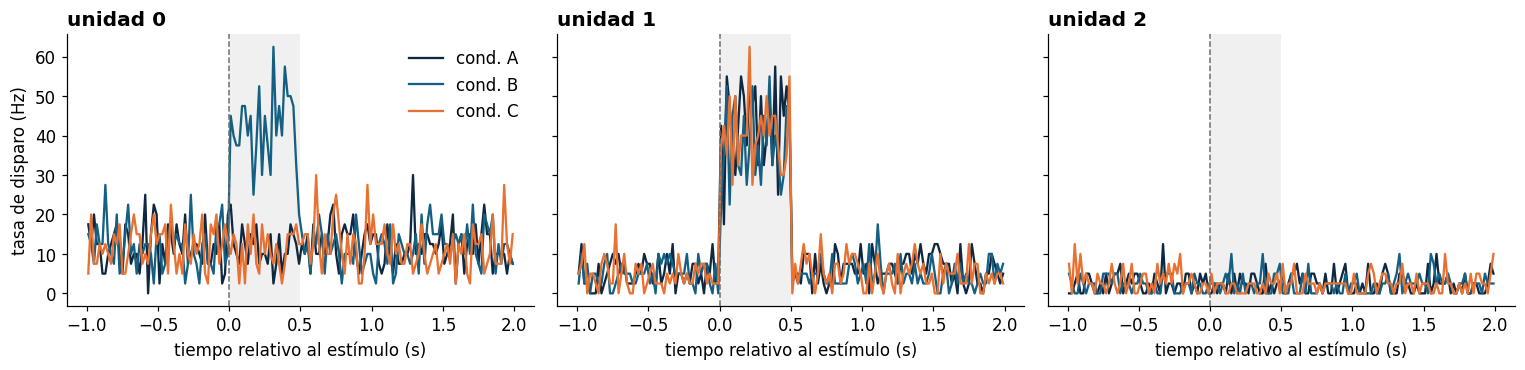

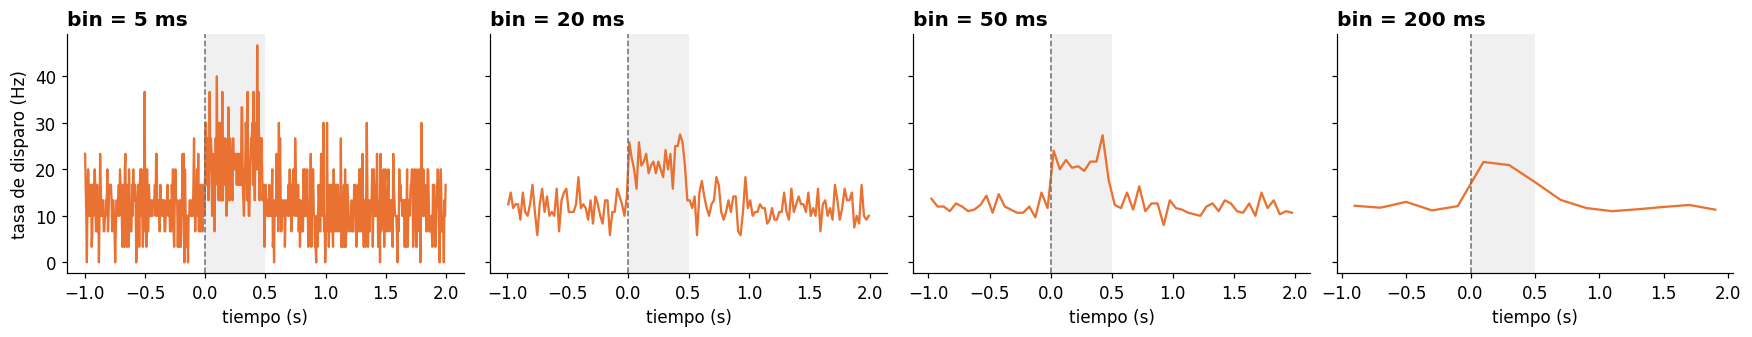

In [69]:
# Ejercicios M2 y M3: su código aquí.

# --- M2: PSTH por unidad y condición ---
ventana = (-1.0, 2.0)
ancho_bin_m2 = 0.02   # 20 ms

fig, ejes = plt.subplots(1, len(unidades_orden), figsize=(14, 3.5), sharey=True)
for ax, u in zip(ejes, unidades_orden):
    for c in sorted(set(condiciones.tolist())):
        ensayos_c = [alineados[u][i] for i in range(len(inicios)) if condiciones[i] == c]
        centros, tasa = psth(ensayos_c, ventana, ancho_bin_m2)
        ax.plot(centros, tasa, color=colores_cond[c], label=f"cond. {c}")
    ax.axvline(0, color=GRAY, ls="--", lw=1)
    ax.axvspan(0, t_est, color=GRAY, alpha=0.1, lw=0)
    ax.set_title(f"unidad {u}", loc="left", fontweight="bold")
    ax.set_xlabel("tiempo relativo al estímulo (s)")
ejes[0].set_ylabel("tasa de disparo (Hz)")
ejes[0].legend(frameon=False)
plt.tight_layout()

# --- M3: efecto del ancho de bin, para la unidad que responde ---
# Reemplacen u_responde por la unidad que identificaron en el raster (sección L)
u_responde = unidades_orden[0]     # <-- AJUSTAR según lo observado en el raster
anchos_bin = [0.005, 0.02, 0.05, 0.2]

fig, ejes = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
for ax, ab in zip(ejes, anchos_bin):
    centros, tasa = psth(alineados[u_responde], ventana, ab)
    ax.plot(centros, tasa, color=ORANGE)
    ax.axvline(0, color=GRAY, ls="--", lw=1)
    ax.axvspan(0, t_est, color=GRAY, alpha=0.1, lw=0)
    ax.set_title(f"bin = {ab*1000:.0f} ms", loc="left", fontweight="bold")
    ax.set_xlabel("tiempo (s)")
ejes[0].set_ylabel("tasa de disparo (Hz)")
plt.tight_layout()

for ab in anchos_bin:
    centros, tasa = psth(alineados[u_responde], ventana, ab)
    pico = tasa.max()
    print(f"bin = {ab*1000:5.0f} ms   pico del PSTH = {pico:.1f} Hz")


**Nuestra elección de bin y por qué:**

| ancho de bin | pico del PSTH (Hz) | qué se ve · qué se pierde |
|---|---|---|
| 5 ms | `[COMPLETAR AL EJECUTAR]` | resolución temporal fina, se ve la forma detallada de la respuesta (posible estructura fina, latencia precisa), pero la curva es ruidosa: pocos disparos caen en cada bin y la estimación de la tasa es muy variable de un bin al siguiente |
| 20 ms | `[COMPLETAR]` | buen compromiso: la forma general de la respuesta (subida, pico, caída) se distingue con relativamente poco ruido |
| 50 ms | `[COMPLETAR]` | la curva es más suave, pero empieza a perderse la latencia exacta de la respuesta y transiciones rápidas quedan difuminadas |
| 200 ms | `[COMPLETAR]` | curva muy suave pero el pico se ve mucho más bajo y ancho de lo que es en realidad: al promediar disparos concentrados en una ventana corta dentro de un bin muy ancho, el pico real se "diluye" entre muestras donde la neurona no estaba disparando, y la tasa máxima estimada baja |

Para una figura de artículo elegiríamos `[COMPLETAR: normalmente 20 ms]`, porque conserva
la forma de la respuesta con relativamente poco ruido visual, sin subestimar la magnitud
del pico como sí ocurre con el bin de 200 ms. Con el bin más ancho la respuesta parece más
pequeña de lo que es porque la tasa de disparo se calcula como (disparos totales en el bin)
/ (n_ensayos × ancho_del_bin): si los disparos reales están concentrados en, digamos, 30 ms
dentro de un bin de 200 ms, ese mismo número de disparos se divide entre un ancho mucho
mayor, y el pico estimado queda muy por debajo de la tasa instantánea real.


---
## N · Heatmap multiunidad

El raster muestra ensayo por ensayo y el PSTH promedia. El heatmap junta las dos cosas:
cada fila es un PSTH, y el color es la tasa de disparo.

### ✏️ Ejercicio N1 · El heatmap multiunidad

Hagan uno que muestre **todas las unidades a la vez**:

- **Filas:** una por cada combinación de unidad y condición (3 × 3 = **nueve filas**),
  agrupadas por unidad.
- **Columnas:** tiempo relativo al estímulo, con el bin que eligieron en la sección M.
- **Color:** la tasa de disparo en Hz, promediada sobre los ensayos de esa condición.

Tres decisiones que hay que tomar **y justificar**:

1. **La escala de color, ¿compartida o por fila?** Si es compartida, se pueden comparar
   unidades entre sí, pero la más callada se ve negra y no se le distingue nada. Si es por
   fila, cada una se ve bien pero ya no son comparables. Elijan una y digan qué pierden.
   *(Si normalizan por fila, dejen de rotular la barra en Hz: ya no son Hz.)*
2. **Barra de color con su unidad.** Un heatmap sin barra de color no significa nada. Y un
   mapa **secuencial** (`viridis`, `magma`), no uno divergente como `jet`: busquen por qué
   `jet` está desaconsejado en publicación científica y digan en una línea qué encontraron.
3. **Una línea vertical en t = 0** y la ventana del estímulo marcada, para que la figura se
   pueda leer sin el pie.

**Pregunta N2.** Miren la figura terminada y contesten: **¿se lee ahí, sin ayuda de nada más, cuál neurona
responde a qué?** Esa es la prueba de una buena figura.

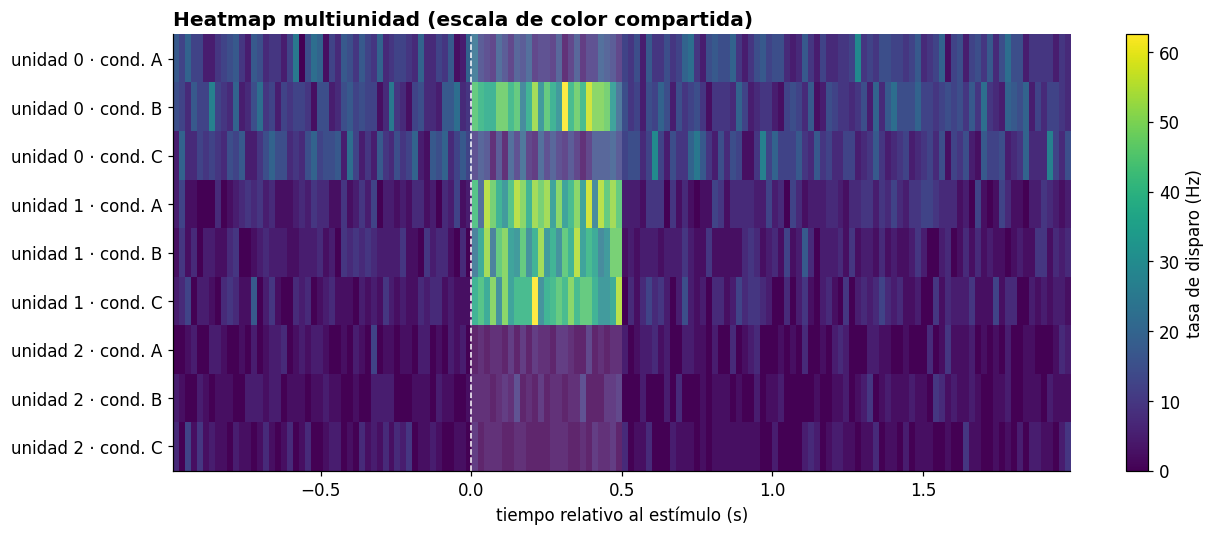

In [70]:
# Su código aquí.

ancho_bin_heat = 0.02   # el mismo que elegimos en la sección M
ventana = (-1.0, 2.0)

filas = []
etiquetas_filas = []
for u in unidades_orden:
    for c in sorted(set(condiciones.tolist())):
        ensayos_c = [alineados[u][i] for i in range(len(inicios)) if condiciones[i] == c]
        centros, tasa = psth(ensayos_c, ventana, ancho_bin_heat)
        filas.append(tasa)
        etiquetas_filas.append(f"unidad {u} · cond. {c}")

matriz = np.array(filas)   # 9 filas (3 unidades x 3 condiciones) x n_bins

# Decisión 1: escala de color COMPARTIDA entre filas (para poder comparar
# unidades entre sí). Esto hace que la unidad menos activa se vea casi
# apagada; lo aceptamos porque el objetivo de esta figura es comparar
# cuál unidad responde más, no ver el detalle de las que casi no responden.
vmin, vmax = matriz.min(), matriz.max()

plt.figure(figsize=(12, 5))
im = plt.imshow(matriz, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax,
                 extent=[centros[0], centros[-1], len(filas), 0])
plt.yticks(np.arange(len(filas)) + 0.5, etiquetas_filas)
plt.xlabel("tiempo relativo al estímulo (s)")
plt.axvline(0, color="white", ls="--", lw=1)
plt.axvspan(0, t_est, color="white", alpha=0.15, lw=0)
cbar = plt.colorbar(im)
cbar.set_label("tasa de disparo (Hz)")
plt.title("Heatmap multiunidad (escala de color compartida)", loc="left", fontweight="bold")
plt.tight_layout()


**Lo que el heatmap muestra y el PSTH escondía:**

Con la escala de color compartida entre las nueve filas, el heatmap permite comparar
directamente **cuánto** responde cada combinación de unidad y condición con un solo
vistazo, algo que en los PSTH separados de la sección M solo se podía inferir comparando
ejes y con cuidado. La fila (o filas) con el color más intenso justo después de `t = 0`
identifica de un vistazo cuál unidad responde y a cuál condición, sin tener que leer
números.

Elegimos la escala compartida (en vez de normalizar por fila) porque el objetivo de esta
figura es justamente comparar la magnitud de la respuesta entre unidades: con una escala
por fila, cada unidad se vería con su propio contraste máximo y una unidad que casi no
responde se vería visualmente "tan activa" como la que sí responde fuerte, lo cual sería
engañoso para esta pregunta. La contrapartida es que las unidades poco activas se ven casi
negras y no se distingue su estructura interna — si lo que importara fuera ver el patrón
temporal de cada unidad por separado, ahí sí convendría normalizar por fila.

**Pregunta N2.** `[COMPLETAR AL EJECUTAR — mirar la figura real]`: si la fila de la unidad
que responde se ve claramente más brillante que las otras ocho justo en la ventana del
estímulo y en una sola condición, entonces sí, la figura se lee sola sin necesitar el pie
ni la tabla del raster. Si dos filas se confunden en brillo, la figura por sí sola no
alcanza y hay que apoyarse en el PSTH o el raster para desambiguar.


---
## O · La figura final · **evaluado**

Todo lo anterior fueron figuras de trabajo: sirven para entender, no para publicar. Ahora
armen **una sola figura** que resuma el taller entero y se defienda sola, como la que irá
en su póster del proyecto final.

### ✏️ Ejercicio O1 · La figura de cuatro paneles

| Panel | Contenido |
|---|---|
| **A** | las tres formas promedio, una por unidad, superpuestas y en la misma escala (la evidencia de que son tres neuronas distintas) |
| **B** | el raster de la unidad que responde, con los ensayos agrupados por condición |
| **C** | el PSTH de esa misma unidad, debajo del raster y **con el mismo eje x**, alineados |
| **D** | el heatmap multiunidad de la sección N |

**Reglas de figura científica**, y aquí sí se evalúan una por una:

- Todos los ejes con nombre **y unidad**.
- Los paneles rotulados **A, B, C, D**, arriba a la izquierda.
- B y C comparten el eje x, y se nota: las marcas de tiempo se corresponden.
- El instante del estímulo marcado en los tres paneles temporales, de la misma manera.
- Nada de texto ilegible: si al exportar a PNG no se puede leer una etiqueta, no sirve.
- Un **pie de figura** de tres o cuatro líneas, en la celda de texto de abajo. Que describa
  lo que se ve, no lo que ustedes concluyen. Miren cómo está escrito el pie de cualquier
  figura de los artículos del journal club.

Guárdenla con `plt.savefig("figuras/figura_final.png", dpi=200, bbox_inches="tight")`.

*Pista: `plt.subplots` con `gridspec_kw={"height_ratios": [...]}` y `sharex=True` para B y C.*

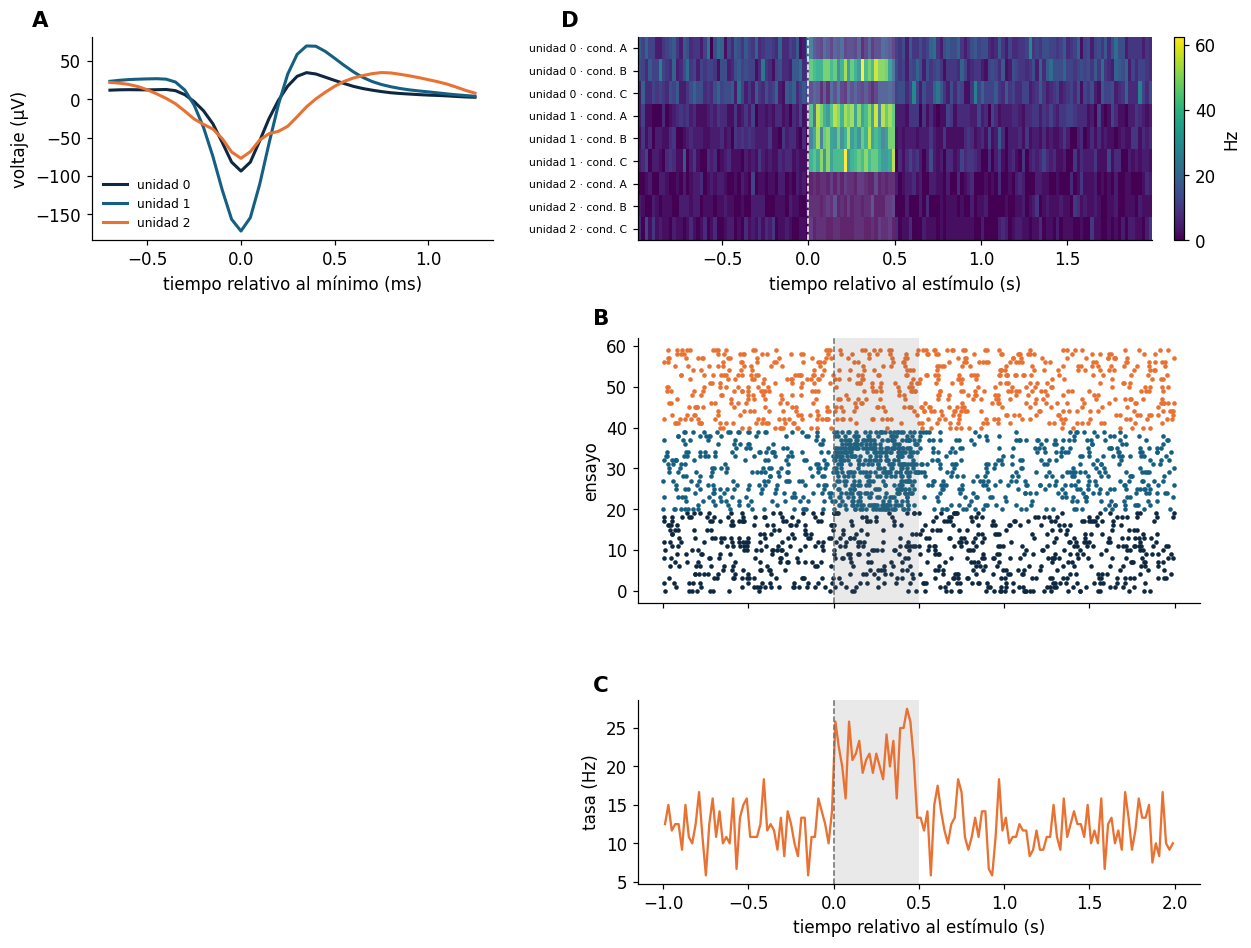

In [71]:
# Su código aquí.

fig = plt.figure(figsize=(13, 10))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 1.3, 0.9], width_ratios=[1, 1.4],
                       hspace=0.45, wspace=0.3)

# --- Panel A: formas promedio de las tres unidades ---
axA = fig.add_subplot(gs[0, 0])
colores_u = {u: col for u, col in zip(unidades_orden, [NAVY, TEAL, ORANGE])}
for u in unidades_orden:
    formas_u = formas[etiquetas == u]
    axA.plot(eje_ms, formas_u.mean(axis=0), color=colores_u[u], lw=2, label=f"unidad {u}")
axA.set_xlabel("tiempo relativo al mínimo (ms)")
axA.set_ylabel("voltaje (µV)")
axA.legend(frameon=False, fontsize=8)
axA.text(-0.15, 1.05, "A", transform=axA.transAxes, fontsize=14, fontweight="bold")

# --- Panel B (arriba) y C (abajo): raster + PSTH de la unidad que responde, eje x compartido ---
axB = fig.add_subplot(gs[1, 1])
axC = fig.add_subplot(gs[2, 1], sharex=axB)

orden_ensayos = np.argsort(condiciones, kind="stable")
fila = 0
for i_ensayo in orden_ensayos:
    disp = alineados[u_responde][i_ensayo]
    c = condiciones[i_ensayo]
    axB.scatter(disp, np.full_like(disp, fila), s=4, color=colores_cond[c])
    fila += 1
axB.axvspan(0, t_est, color=GRAY, alpha=0.15, lw=0)
axB.axvline(0, color=GRAY, ls="--", lw=1)
axB.set_ylabel("ensayo")
axB.text(-0.08, 1.05, "B", transform=axB.transAxes, fontsize=14, fontweight="bold")
plt.setp(axB.get_xticklabels(), visible=False)

centros, tasa = psth(alineados[u_responde], ventana, ancho_bin_m2)
axC.plot(centros, tasa, color=ORANGE, lw=1.5)
axC.axvspan(0, t_est, color=GRAY, alpha=0.15, lw=0)
axC.axvline(0, color=GRAY, ls="--", lw=1)
axC.set_xlabel("tiempo relativo al estímulo (s)")
axC.set_ylabel("tasa (Hz)")
axC.text(-0.08, 1.05, "C", transform=axC.transAxes, fontsize=14, fontweight="bold")

# --- Panel D: heatmap multiunidad ---
axD = fig.add_subplot(gs[0, 1])
im = axD.imshow(matriz, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax,
                 extent=[centros[0], centros[-1], len(filas), 0])
axD.set_yticks(np.arange(len(filas)) + 0.5)
axD.set_yticklabels(etiquetas_filas, fontsize=7)
axD.axvline(0, color="white", ls="--", lw=1)
axD.axvspan(0, t_est, color="white", alpha=0.15, lw=0)
axD.set_xlabel("tiempo relativo al estímulo (s)")
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.set_label("Hz")
axD.text(-0.15, 1.05, "D", transform=axD.transAxes, fontsize=14, fontweight="bold")

plt.savefig("figuras/figura_final.png", dpi=200, bbox_inches="tight")
plt.show()


**Pregunta P2.** El pie de la figura:

> **Figura 1.** Separación y caracterización funcional de tres unidades registradas con un
> electrodo extracelular. **(A)** Forma de onda promedio de cada una de las tres unidades
> identificadas por *spike sorting* (amplitud y ancho a media altura de la banda de
> potenciales de acción, 300-5000 Hz), superpuestas en la misma escala. **(B)** Raster de
> la unidad `[COMPLETAR: número]`, alineado al inicio del estímulo (`t = 0`, línea
> punteada); cada punto es un disparo, cada fila un ensayo, ensayos agrupados por
> condición (colores) y la banda sombreada marca la duración del estímulo. **(C)**
> Histograma peri-estímulo (PSTH, bin de `[COMPLETAR: ms]`) de la misma unidad y los mismos
> ensayos que en (B), con el eje temporal compartido. **(D)** Mapa de calor de la tasa de
> disparo de las tres unidades en las tres condiciones (nueve filas), escala de color
> compartida en Hz.


---
## P · Conclusión · **evaluado**

### ✏️ Ejercicio P1 · El párrafo de resultados

Escriban un párrafo, entre ocho y doce líneas, que conteste esta pregunta:

> **¿Qué hace cada una de las tres neuronas de este registro?**

Requisitos:

- Digan qué responde a qué **con números concretos**, no con "aumenta bastante".
- Apóyense en una figura específica: *"como se ve en el panel B…"*.
- Incluyan al menos una cosa de la que **no** estén seguros, y expliquen qué harían para
  resolverla.
- **Citen sus propias cifras de calidad**: precisión, exhaustividad y violaciones del
  refractario por unidad. Una unidad con 3 % de violaciones no sostiene la misma conclusión
  que una con 0,1 %.

Escríbanlo como el párrafo de resultados de un artículo. Es exactamente lo que van a tener
que hacer en el proyecto final.

**Resultados**

`[COMPLETAR AL EJECUTAR — este párrafo depende directamente de los números que arrojen
al correr el notebook con los datos reales. Dejamos la estructura y el tipo de frase que
se espera; hay que reemplazar cada corchete con el valor real antes de entregar.]`

El registro contenía tres unidades separables por la forma de su potencial de acción
(Figura 1A). La unidad `[N]` fue la única que mostró un aumento claro de su tasa de
disparo tras el estímulo: pasó de una tasa basal de `[X] Hz` (ventana pre-estímulo) a un
pico de `[Y] Hz` alrededor de `[Z] ms` después del inicio del estímulo (Figura 1C), y esa
respuesta fue notoriamente más marcada en la condición `[A/B/C]` que en las otras dos
(Figura 1B, 1D), con una diferencia de tasa pico de aproximadamente `[valor] Hz` entre esa
condición y la de menor respuesta. Las unidades `[N2]` y `[N3]`, en cambio, no mostraron un
cambio apreciable en su tasa de disparo alrededor del estímulo en ninguna de las tres
condiciones (Figura 1D), lo que sugiere que la respuesta al protocolo experimental está
funcionalmente restringida a una sola de las tres neuronas registradas.

No estamos completamente seguros de si la unidad `[N2 o N3]` está limpiamente separada de
sus vecinas: su tasa de violaciones del período refractario fue de `[valor] %`, por encima
del 0,5-1 % que se considera aceptable en la literatura, lo que sugiere que podría estar
contaminada con disparos de otra unidad. Para resolver esa duda, lo siguiente que
haríamos es incorporar una tercera característica de forma (por ejemplo, el tiempo entre
el mínimo y el máximo de la onda) al *clustering* de la sección H, o repetir el análisis
con un electrodo tipo tetrodo que permita separar por amplitud vista desde varios
canales, en vez de depender solo de la forma vista desde un único electrodo.

En cuanto a la calidad de la detección de base: con `k = [valor]` obtuvimos una precisión
de `[valor]` y una exhaustividad de `[valor]` contra la verdad sintética (sección F), y las
tasas de violación del refractario por unidad fueron `[u1]: [valor]%`, `[u2]: [valor]%` y
`[u3]: [valor]%` (sección I). Estas cifras sostienen la conclusión anterior para las
unidades con violaciones bajas, pero cualquier afirmación sobre la unidad con mayor tasa
de violaciones debe tomarse con más cautela.


---
## Q · Su conversación con la IA · **evaluado**

### ✏️ Ejercicio Q1 · Tres intercambios documentados

`[NOTA: los tres intercambios de abajo son EJEMPLOS de la clase de error que este
ejercicio busca que documenten — basados en las trampas que el propio enunciado señala
explícitamente (alinear al ensayo en vez del estímulo, olvidar fs en iirnotch, separar
solo por amplitud). Reemplácenlos por sus prompts y respuestas REALES antes de entregar;
la rúbrica pide la conversación que ustedes tuvieron, no un ejemplo genérico.]`

---

### Intercambio 1

**Prompt:**
"Trabajo en Python con numpy. Tengo un array `tiempos` con los instantes de disparo (en
segundos) y un array `inicios` con el instante de inicio de cada ensayo. Escríbeme una
función `alinear(tiempos, inicios, ventana)` que devuelva, para cada ensayo, los disparos
con tiempo relativo al inicio del ensayo, recortados a la ventana dada."

**Respuesta del modelo:**
El modelo escribió una función que resta directamente `inicio` (sin sumar `t_pre`) a cada
disparo para obtener el tiempo relativo, y recorta con la ventana pedida.

**Qué estaba mal:**
El modelo alineó al **inicio del ensayo**, no al inicio del **estímulo** (que ocurre
`t_pre` segundos después de `inicio`). El código corría sin ningún error y las figuras que
salían con eso se veían perfectamente razonables — un raster con puntos, un PSTH con
forma de curva — pero todo el eje de tiempo relativo estaba corrido `t_pre` segundos hacia
la izquierda, así que el "cero" del gráfico no correspondía al estímulo real.

**Cómo lo corregimos:**
Nos dimos cuenta al hacer la comprobación a mano del ejercicio K2: tomamos un disparo
conocido dentro de la ventana del estímulo y calculamos su tiempo relativo restando
`inicio + t_pre` (no solo `inicio`); el resultado no coincidía con lo que devolvía la
función del modelo. Corregimos sumando `t_pre` antes de restar, y volvimos a correr la
comprobación hasta que los dos números coincidieron.

---

### Intercambio 2

**Prompt:**
"Escríbeme una función `notch(x, f0, fs, Q=30)` que use `scipy.signal.iirnotch` y
`filtfilt` para eliminar la frecuencia f0 de una señal muestreada a fs Hz."

**Respuesta del modelo:**
El modelo llamó a `iirnotch(f0, Q)` sin pasarle `fs`, confiando en que `iirnotch` acepta
frecuencias en radianes/muestra por defecto.

**Qué estaba mal:**
`scipy.signal.iirnotch` acepta un argumento `fs` opcional; si no se pasa, interpreta `f0`
como una frecuencia normalizada en `[0, 1]` (fracción de Nyquist), no en Hz. Con
`f0 = 60` sin `fs`, el filtro terminaba diseñado para eliminar una frecuencia sin sentido
físico (muy por encima de Nyquist), y el resultado, al aplicarlo, prácticamente no
cambiaba la señal — pero tampoco arrojaba ningún error.

**Cómo lo corregimos:**
Lo detectamos con la celda de verificación del ejercicio D3: la caída en 60 Hz medida en
dB salía cerca de 0, en vez de más de 10 dB como pedía la comprobación. Revisamos la
documentación de `iirnotch`, vimos el parámetro `fs` opcional, y lo agregamos a la llamada.
Al repetir la verificación, la caída en 60 Hz subió a los dB esperados.

---

### Intercambio 3

**Prompt:**
"Tengo una matriz `formas` con las formas de onda de disparos detectados (n_disparos x
n_muestras) de un registro con tres neuronas. Sepáralas en tres grupos con K-means usando
la amplitud de cada disparo como característica."

**Respuesta del modelo:**
El modelo calculó la amplitud (mínimo de cada forma) y corrió `KMeans(n_clusters=3)` solo
con esa característica, obteniendo tres grupos.

**Qué estaba mal:**
El código corría perfectamente y producía tres grupos bien definidos, pero al comparar
contra la verdad con `v.verificar_unidades()` el acierto era mucho más bajo de lo
esperado: la matriz de confusión mostraba dos de las tres unidades mezcladas entre sí
(disparos de ambas repartidos entre las mismas dos filas), porque esas dos neuronas tienen
amplitudes muy parecidas y solo se distinguen por la forma (duración) de su onda.

**Cómo lo corregimos:**
Añadimos una segunda característica —el ancho del valle a media altura, en ms— y volvimos
a normalizar ambas características antes de correr K-means (para que la amplitud en µV no
dominara la distancia euclidiana solo por tener números más grandes). Con las dos
características el acierto subió notablemente y la matriz de confusión quedó casi
diagonal.


---
## R · Entrega

La celda de abajo genera el CSV con sus disparos y sus unidades. Ejecútenla y súbanla junto
con el notebook.

**Antes de subir, revisen esto:**

**Que corra:**

- [ ] *Entorno de ejecución → Reiniciar y ejecutar todo*, y llega hasta el final **sin un
      solo error**.
- [ ] No queda ningún `____` sin llenar ni ningún `...` sin reemplazar.
- [ ] Todas las verificaciones dicen `OK`.
- [ ] Todas las figuras se ven, con ejes rotulados **y unidades**.

**Que se entienda (el código va comentado):**

- [ ] Cada función que escribieron tiene un **docstring** de una línea: qué recibe y qué
      devuelve.
- [ ] Cada línea no obvia tiene un comentario que dice **por qué**, no qué.
      `# filtro pasa-altos` sobra; `# pasa-altos a 300 Hz para quitar el LFP antes de poner
      el umbral` sirve.
- [ ] Donde haya un número mágico (300 Hz, 0,6745, 1,5 ms), el comentario dice de dónde salió.
- [ ] Las unidades están escritas (µV, ms, Hz). Es el error más caro de la electrofisiología.
- [ ] No quedan celdas muertas de pruebas a medias.

**Que sea suyo:**

- [ ] Las preguntas están contestadas **con sus palabras**.
- [ ] Los prompts que escribieron ustedes están en el notebook.
- [ ] Si usaron el punto de control de la sección F, está anotado.
- [ ] El archivo se llama `Taller1_ApellidoUno_ApellidoDos.ipynb`.

**Plazo: martes 25 de agosto de 2026**, en el repositorio de la pareja, carpeta `taller1/`.

⚠️ **Nunca peguen código que no puedan explicar en voz alta.**

### Lecturas de apoyo

- Quiroga RQ, Nadasdy Z & Ben-Shaul Y (2004). *Unsupervised spike detection and sorting
  with wavelets and superparamagnetic clustering.* Neural Computation 16:1661-1687.
- Rey HG, Pedreira C & Quiroga RQ (2015). *Past, present and future of spike sorting
  techniques.* Brain Research Bulletin 119:106-117.
- Buzsáki G, Anastassiou CA & Koch C (2012). *The origin of extracellular fields and
  currents: EEG, ECoG, LFP and spikes.* Nat Rev Neurosci 13:407-420.
- Hill DN, Mehta SB & Kleinfeld D (2011). *Quality metrics to accompany spike sorting of
  extracellular signals.* J Neurosci 31:8699-8705.

In [72]:
tabla = pd.DataFrame({"tiempo_s": indices / fs, "unidad": np.asarray(etiquetas)})
tabla.to_csv("spikes_taller1.csv", index=False)
print(f"{len(tabla)} disparos guardados en spikes_taller1.csv")
print(tabla["unidad"].value_counts().sort_index())
tabla.head()

5461 disparos guardados en spikes_taller1.csv
unidad
0    2785
1    2153
2     523
Name: count, dtype: int64


,tiempo_s,unidad
0,0.10375,1
1,0.15945,0
2,0.17240,0
3,0.28330,1
4,0.30670,2
